In [5]:
!pip install soundfile -q
!pip install --upgrade pip -q
!pip install scipy -q
!pip -q install torchaudio -q
!pip install hmmlearn -q
!pip install PyWavelets -q

!pip install lime

ERROR: Invalid requirement: '-': Expected package name at the start of dependency specifier
    -
    ^


In [70]:
from pathlib import Path
import soundfile as sf
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix

from scipy.stats import mannwhitneyu
from scipy.stats import entropy
from itertools import permutations
import math

import shutil
import os

import librosa

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
from scipy.signal import windows
from scipy.signal import spectrogram as scipy_spectrogram, find_peaks
from scipy import signal
from scipy.interpolate import interp1d

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight


from hmmlearn import hmm
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline


import torch
import torchaudio

import lime
import lime.lime_tabular

from collections import defaultdict



FOLDER_DATA1 = Path("/content/drive/MyDrive/Blood_data/selected_blood_records")
FOLDER_DATA2 = Path("/content/drive/MyDrive/Blood_data/artificial_data_2")



In [8]:
import shutil
import os

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
from pathlib import Path

blood_path = Path("/content/drive/MyDrive/Blood_data")

print("Exists:", blood_path.exists())
print("Files/folders inside Blood_data:")
for p in sorted(blood_path.iterdir()):
    print(p.name)

Exists: True
Files/folders inside Blood_data:
.ipynb_checkpoints
__pycache__
artificial_data_2
blood_records_data1
chaotic.py
features.py
merged
models
selected_blood_records


In [10]:
import sys
sys.path.append("/content/drive/MyDrive/Blood_data")

from features import *


In [11]:
import chaotic
from importlib import reload
reload(chaotic)

from chaotic import *

In [12]:
rows=[]
#We look at the parameters of the wav files to see if any of them have a different number of channels or sample rate.
for p in FOLDER_DATA2.glob("*.wav"):
    info = sf.info(p)
    rows.append({
        "filename": p.name,
        "samplerate": info.samplerate,
        "channels": info.channels,
        "subtype": info.subtype
    })

info_sounds = pd.DataFrame(rows)
print(info_sounds)

#I have sample rate = 3000, this means. that the device measures the value of the signal 3000 times per second
#According to the Nyquist formula, the maximum number of periods per second is the sampling rate/2 = 3000/2 = 1500 Hz

       filename  samplerate  channels subtype
0     rec41.wav        3000         1  PCM_16
1     rec71.wav        3000         1  PCM_16
2     rec60.wav        3000         1  PCM_16
3     rec16.wav        3000         1  PCM_16
4     rec65.wav        3000         1  PCM_16
..          ...         ...       ...     ...
229  rec173.wav        3000         1  PCM_16
230  rec177.wav        3000         1  PCM_16
231  rec119.wav        3000         1  PCM_16
232  rec207.wav        3000         1  PCM_16
233  rec197.wav        3000         1  PCM_16

[234 rows x 4 columns]


In [13]:
blood_folder = FOLDER_DATA1
indices_file = Path("/content/drive/MyDrive/Blood_data/blood_records_data1/inds1.npy")  # file with indeces
conclusions_file = Path("/content/drive/MyDrive/Blood_data/blood_records_data1/conclusions.txt")  # file with conclusions

output_folder = Path("/content/drive/MyDrive/Blood_data/selected_blood_records")
output_folder.mkdir(exist_ok=True, parents=True)

##select files by index and save them in another file

In [ ]:

# import shutil

# selected_indices = np.load(indices_file)
# print(f"    Indeces downloaded: {len(selected_indices)}")


# # Get all files

# all_files = sorted(
#     blood_folder.glob("rec*.wav"),
#     key=lambda x: int(x.stem.replace('rec', ''))
# )
# file_map = {}
# for f in all_files:
#     idx = int(f.stem.replace('rec', ''))
#     file_map[idx] = f

# copied = 0
# skipped = []

# for idx in selected_indices:
#     if idx == 0:
#         skipped.append(idx)
#         continue

#     if idx not in file_map:
#         skipped.append(idx)
#         continue

#     source_file = file_map[idx]
#     dest_file = output_folder / source_file.name
#     shutil.copy2(source_file, dest_file)
#     copied += 1


# print(f"\n Copied: {copied}")
# print(f" Skipped indeces: {len(skipped)}")


# work with records labels files

I needed to match the conclusions.txt files with the labels and the record number. Next, I wrote functions for parsing the file with labels, creating a table with labels and record numbers, adding a binary classification, creating a dictionary from the audio recordings of both datasets, and adding a binary classification of pathology or normal.


In [ ]:
# import re
# import os
# import pandas as pd

# def read_conclusions(filepath):
#     with open(filepath, 'r', encoding='windows-1251') as f:
#         lines = [line.strip() for line in f.readlines()]
#     return lines

# def parse_filename(filename):

#     Parses the file name in the format rec4.wav, rec42.wav

#     name = filename.replace('.wav', '').replace('.WAV', '')
#     match = re.match(r'rec(\d+)', name)

#     if not match:
#         return (None, None)

#     recording_num = int(match.group(1))

#     return (recording_num, None)

# def find_wav_files(folder):
#     wav_files = []

#     for file in os.listdir(folder):
#         if file.lower().endswith('.wav'):
#             wav_files.append(file)

#     return sorted(wav_files, key=lambda x: int(re.search(r'(\d+)', x).group(1)) if re.search(r'(\d+)', x) else 0)

# def create_labels_table(wav_files, conclusions):
#     data = []

#     for filename in wav_files:
#         recording_num, segment_num = parse_filename(filename)
#         if recording_num is not None and 0 <= recording_num < len(conclusions):
#             label = conclusions[recording_num]
#         else:
#             label = "UNKNOWN"

#         data.append({
#             'filename': filename,
#             'recording_number': recording_num,
#             'label': label
#         })

#     return pd.DataFrame(data)

# conclusions = read_conclusions(conclusions_file)
# wav_files = find_wav_files(output_folder)

# labels_table = create_labels_table(wav_files, conclusions)
# csv_path = output_folder / 'labels_table.csv'
# labels_table.to_csv(csv_path, index=False, encoding='utf-8-sig')


# display(labels_table.head(20))


# # Check for unknown
# unknown = labels_table[labels_table['label'] == 'UNKNOWN']
# if len(unknown) > 0:
#     display(unknown)


In [ ]:
# #Binary classification

# LABELS_CSV = Path("/content/drive/MyDrive/Blood_data/selected_blood_records/labels_table.csv")

# LABELS_TABLE = pd.read_csv(LABELS_CSV)

# labels_table = LABELS_TABLE.copy()
# labels_table["filename"] = labels_table["filename"].astype(str).apply(lambda s: Path(s).name)
# labels_table["label"] = labels_table["label"].astype(str).str.strip().str.lower()

# def label_to_binary(x):
#     s = str(x).strip().lower()
#     if s == "good":
#         return "normal"
#     elif (s == 'стеноз' or s == "тромбоз"):
#       return "path"
#     else:
#       return None

# labels_table["label_bin"] = labels_table["label"].apply(label_to_binary)
# labels_table = labels_table[labels_table["label_bin"].notna()]
# labels_table = labels_table.drop_duplicates(subset=["filename"], keep="first")
# label_map = dict(zip(labels_table["filename"], labels_table["label_bin"]))

# print("Label distribution:", labels_table["label_bin"].value_counts().to_dict())
# print("Unique labeled files:", len(label_map))

# # three classes
# def normalize_diag(s):
#     if s == "good":
#         return "normal"
#     if s == "стеноз":
#         return "stenosis"
#     if s == "тромбоз":
#         return "thrombosis"
#     return None

# labels_table["label_diag"] = labels_table["label"].apply(normalize_diag)

# # check for duplicates
# labels_table = labels_table.drop_duplicates(subset=["filename"], keep="first")

# label_map_diag = dict(zip(labels_table["filename"], labels_table["label_diag"]))

# print(pd.Series(label_map_diag).value_counts())
# print(label_map)
# print(labels_table.head())
# print(label_map_diag)

In [ ]:
# import shutil

# FOLDER_MERGED = Path("/content/drive/MyDrive/Blood_data/merged")
# FOLDER_MERGED.mkdir(exist_ok=True, parents=True)

# # copy data from first dataset with prefix data1_
# for p in FOLDER_DATA1.glob("*.wav"):
#     shutil.copy2(p, FOLDER_MERGED / f"data1_{p.name}")

# # copy data from secobnd dataset with prefix data2_
# for p in FOLDER_DATA2.glob("*.wav"):
#     shutil.copy2(p, FOLDER_MERGED / f"data2_{p.name}")

# print(" merged:", len(list(FOLDER_MERGED.glob("*.wav"))))

In [ ]:
# label_map_merged = {}

# #  data from first dataset take from  label_map
# for fname, label in label_map.items():
#     label_map_merged[f"data1_{fname}"] = label

# #  second dataset
# for i in range(234):
#     fname = f"rec{i}.wav"
#     label = "normal" if i <= 160 else "path"
#     label_map_merged[f"data2_{fname}"] = label

# print("All files in label_map_merged:", len(label_map_merged))


In [ ]:
# files_in_folder = set(p.name for p in FOLDER_MERGED.glob("*.wav"))
# files_in_map = set(label_map_merged.keys())
# no_label = files_in_folder - files_in_map

# print(f"files in merged: {len(files_in_folder)}")
# print(f"files in label_map_merged: {len(files_in_map)}")
# print(f"files without label: {len(no_label)}")
# print(f"\nLabels distribution:")
# print(pd.Series(label_map_merged).value_counts())

In [ ]:

# label_table_merged = pd.DataFrame([
#     {"filename": fname, "label": label}
#     for fname, label in label_map_merged.items()
# ])

# print(f"All recordings: {len(label_table_merged)}")

# csv_path = FOLDER_MERGED / "labels_merged.csv"
# label_table_merged.to_csv(csv_path, index=False, encoding='utf-8-sig')

# from google.colab import files
# files.download(str(csv_path))

In [14]:
FOLDER = Path("/content/drive/MyDrive/Blood_data/merged")
label_table_merged = pd.read_csv("/content/drive/MyDrive/Blood_data/merged/labels_merged.csv")
label_map_merged = dict(zip(label_table_merged["filename"], label_table_merged["label"]))

print(f"Records len: {len(label_map_merged)}")
print(label_table_merged["label"].value_counts())
print(label_table_merged[30:40])

Records len: 351
label
normal    259
path       92
Name: count, dtype: int64
           filename   label
30  data1_rec36.wav  normal
31  data1_rec37.wav  normal
32  data1_rec38.wav    path
33  data1_rec39.wav    path
34  data1_rec40.wav  normal
35  data1_rec41.wav  normal
36  data1_rec42.wav    path
37  data1_rec43.wav  normal
38  data1_rec44.wav  normal
39  data1_rec48.wav  normal


# Entropy complexity
### A method that can be used to determine how unpredictable a sound signal is and whether there is any ordered complexity or noise present.

In [15]:
#Test to calculate entropy and complexity for a single audio recording
y, sr = sf.read("/content/drive/MyDrive/Blood_data/merged/data1_rec11.wav")

m = 5
tau = 10
H, C = entropy_complexity(y, m, tau)

print("H =", H, "C =", C)

H = 0.9745197988417674 C = 0.04376649641092424


## The section of finding a suitable Tau


### Vizualization of different tau and m

Then I thought that it would be easier to find the optimal m and tau if I could see the pathological and normal records.

In [ ]:

# df_feat = compute_features_for_folder(
#     FOLDER, label_map_merged,
#     m_values=(3,4),
#     tau_values=range(1, 11)
# )

# display(df_feat.head())

# features_csv_path = Path("/content/drive/MyDrive/Blood_data/merged/features_csv_2.csv")
# df_feat.to_csv(features_csv_path, index=False, encoding='utf-8-sig')

# from google.colab import files
# files.download(features_csv_path)

# The nearest neighbor method shows that the best ratio is m = 4, tau = 2

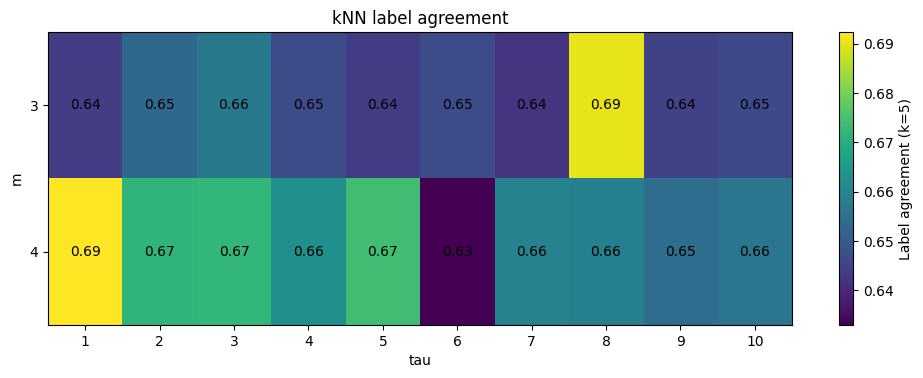

In [16]:
from sklearn.neighbors import NearestNeighbors

features_csv_path = Path("/content/drive/MyDrive/Blood_data/merged/features_csv_2.csv")
df_feat = pd.read_csv(features_csv_path)


df_knn_perm = knn_perm_heatmaps(df_feat, m_values=(3,4), tau_values=range(1,11), k=5, n_perm=2000)



In [ ]:
# # Counting m=5 with different tau
# df_feat_m5 = compute_features_for_folder(
#     FOLDER, label_map_merged,
#     m_values=(5,),
#     tau_values=range(1, 11)
# )

# print(df_feat_m5["label"].value_counts())
# print(df_feat_m5.head())

# # separatly m=5
# csv_path_m5 = Path("/content/drive/MyDrive/Blood_data/merged/features_m5.csv")
# df_feat_m5.to_csv(csv_path_m5, index=False, encoding='utf-8-sig')

# # merge with m=3,4
# df_feat_all = pd.concat([df_feat, df_feat_m5], ignore_index=True)
# print(f"\nВсего строк в df_feat_all: {len(df_feat_all)}")
# print(df_feat_all["m"].value_counts())

# csv_path_all = Path("/content/drive/MyDrive/Blood_data/merged/features_all_m345.csv")
# df_feat_all.to_csv(csv_path_all, index=False, encoding='utf-8-sig')



In [17]:

df_feat_m5 = pd.read_csv("/content/drive/MyDrive/Blood_data/merged/features_m5.csv")
df_feat_all = pd.read_csv("/content/drive/MyDrive/Blood_data/merged/features_all_m345.csv")


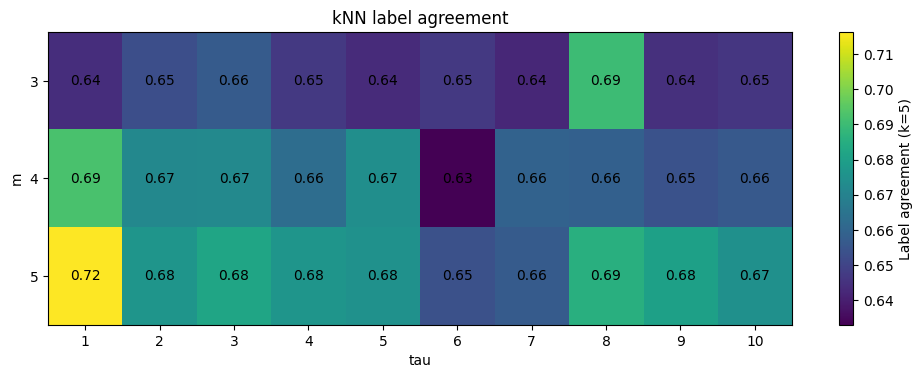

In [18]:
# KNN agreement for all m
df_knn_m5 = knn_perm_heatmaps(
    df_feat_all,
    m_values=(3, 4, 5),
    tau_values=range(1, 11),
    k=5,
    n_perm=2000
)

# Entropy-Complexity plot for m=5 tau = 1

Normal: 259, Path: 92


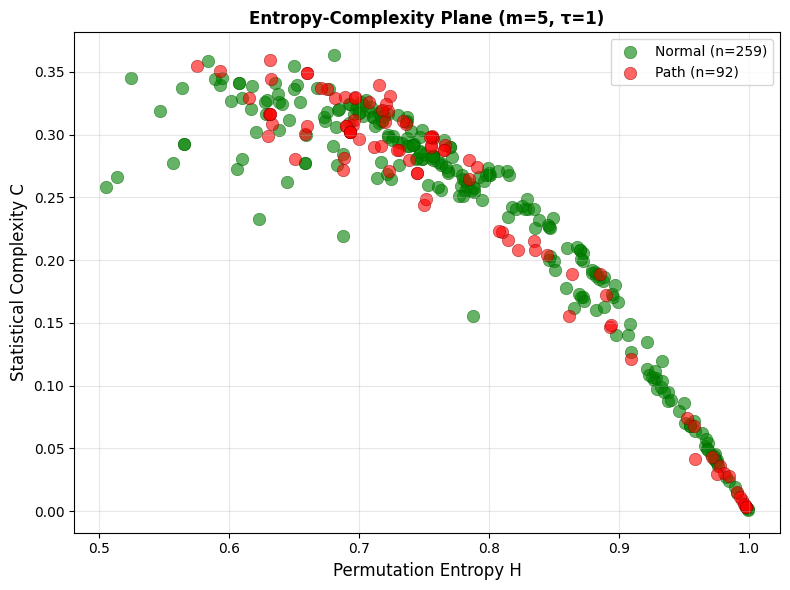

In [19]:
# Scatter for m=5, tau=1
m, tau = 5, 1
df_plot = df_feat_all[(df_feat_all["m"] == m) & (df_feat_all["tau"] == tau)].copy()

normal = df_plot[df_plot["label"] == "normal"]
path   = df_plot[df_plot["label"] == "path"]

print(f"Normal: {len(normal)}, Path: {len(path)}")

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(normal["H"], normal["C"], c="green",
           label=f"Normal (n={len(normal)})",
           alpha=0.6, s=80, edgecolors="darkgreen", linewidth=0.5)
ax.scatter(path["H"], path["C"], c="red",
           label=f"Path (n={len(path)})",
           alpha=0.6, s=80, edgecolors="darkred", linewidth=0.5)

ax.set_xlabel("Permutation Entropy H", fontsize=12)
ax.set_ylabel("Statistical Complexity C", fontsize=12)
ax.set_title(f"Entropy-Complexity Plane (m={m}, τ={tau})", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("best_m5_tau1.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
features_csv_path2 = Path("/content/drive/MyDrive/Blood_data/merged/features_csv_2.csv")
df_feat2 = pd.read_csv(features_csv_path2)

print(df_feat2.head(10))
print("\nColumns:", df_feat2.columns.tolist())
print("\nLabels distribution:", df_feat2["label"].value_counts())

          filename   label  m  tau         H         C    sr      n
0  data1_rec10.wav  normal  3    1  0.753661  0.184090  3000  13360
1  data1_rec10.wav  normal  3    2  0.876708  0.104374  3000  13360
2  data1_rec10.wav  normal  3    3  0.936273  0.057278  3000  13360
3  data1_rec10.wav  normal  3    4  0.966591  0.031044  3000  13360
4  data1_rec10.wav  normal  3    5  0.984825  0.014407  3000  13360
5  data1_rec10.wav  normal  3    6  0.997018  0.002888  3000  13360
6  data1_rec10.wav  normal  3    7  0.999097  0.000905  3000  13360
7  data1_rec10.wav  normal  3    8  0.993103  0.006978  3000  13360
8  data1_rec10.wav  normal  3    9  0.986715  0.013485  3000  13360
9  data1_rec10.wav  normal  3   10  0.986857  0.013317  3000  13360

Columns: ['filename', 'label', 'm', 'tau', 'H', 'C', 'sr', 'n']

Labels distribution: label
normal    5180
path      1840
Name: count, dtype: int64


In [21]:
m_best = 5
tau_best = 1

df_hc = df_feat_all[
    (df_feat_all["m"] == m_best) &
    (df_feat_all["tau"] == tau_best)
].copy()

hc_features = ["H", "C"]
y_true = (df_hc["label"] == "path").astype(int).values

print(f"ROC AUC for Entropy-Complexity features (m={m_best}, tau={tau_best})")
print("\n ")

for feat in hc_features:
    scores = df_hc[feat].values
    mask = ~np.isnan(scores)

    fpr, tpr, _ = roc_curve(y_true[mask], scores[mask])
    roc_auc = auc(fpr, tpr)

    if roc_auc < 0.5:
        fpr, tpr, _ = roc_curve(y_true[mask], -scores[mask])
        roc_auc = auc(fpr, tpr)

    print(f"{feat}: AUC = {roc_auc:.3f}")

ROC AUC for Entropy-Complexity features (m=5, tau=1)

 
H: AUC = 0.550
C: AUC = 0.560


# Spectrums


In [ ]:
label_table_merged[45:60]

,filename,label
45,data1_rec56.wav,normal
46,data1_rec61.wav,normal
47,data1_rec62.wav,normal
48,data1_rec63.wav,normal
49,data1_rec64.wav,normal
50,data1_rec66.wav,path
51,data1_rec67.wav,normal
52,data1_rec68.wav,normal
53,data1_rec69.wav,path
54,data1_rec70.wav,normal



* **compute_spectrogram_torchaudio** - converts an audio recording into a power spectrogram, namely, it normalizes the signal (removes the constant component so that there is no peak at zero) and turns it into a tensor (a signal is an array of numbers, for torchaudio to read it, you need to make it a tensor), then applies a short-time Fourier transform (a regular one will not work, because it will not show the frequency dynamics, it just indicates its presence) with a Hann window (the signal is cut into overlapping frames, in each of which the power spectrum is calculated (the power at each frequency). Because the STFT cuts off a piece at the ends, jumps are obtained, to eliminate them, a Hann window is used, which smooths the ends), the result is converted to decibels. The function returns frequencies, time points, and the spectrogram itself (a matrix of numbers, where each cell represents the signal power at a given frequency; dark colors indicate low power, light colors indicate high power).
* **detect_whistles_in_spectrogram** - Searches for "whistles" (pronounced "whistles"), i.e., pronounced frequency peaks in each time frame. First, the spectrogram is trimmed by range, and for each time window (spectrogram column), peaks are found using scipy.find_peaks, ensuring that the peak prominence is at least min_prom_dB dB. Then, only pronounced peaks are retained and low frequencies are discarded. The function returns a list of found points consisting of tuples (time, frequency, power), all found frequencies, and the trimmed spectrogram.
* **plot_spectrogram_with_whistles** - Spectrogram visualization, where the whistle points (peaks) are marked on the spectrogram.


In [22]:
def plot_spectrogram_with_whistles(f_b, t, S_b, whistle_points, title="", fmax_plot=800):
    plt.figure(figsize=(12, 5))
    plt.pcolormesh(t, f_b, S_b, shading="auto")
    plt.ylim(0, fmax_plot)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.colorbar(label="Power (dB)")

    if whistle_points is not None and len(whistle_points) > 0:
        plt.scatter(whistle_points[:, 0], whistle_points[:, 1], s=12, marker="o")

    plt.show()


In [23]:

path_files = [p for p in sorted(FOLDER.glob("*.wav"))
              if p.name in label_map_merged and label_map_merged[p.name] == "path"]

# Testing sensitivity to the prominence threshold
for min_prom in [5.0, 8.0, 12.0]:
    total = 0
    for p in path_files:
        y_t, sr = torchaudio.load(str(p))
        y = y_t.mean(dim=0).numpy()
        f, tt, Sxx_db = compute_spectrogram_torchaudio(y, sr, n_fft=512, hop_length=128)
        _, peak_freqs, _ = detect_whistles_in_spectrogram(
            f, tt, Sxx_db,
            fmin=0, fmax=min(1500, sr / 2),
            min_prom_db=min_prom,
            max_peaks_per_frame=3,
            min_freq_hz=80
        )
        total += len(peak_freqs)
    print(f"  min_prom_db={min_prom}: found picks = {total}")



  min_prom_db=5.0: found picks = 87695
  min_prom_db=8.0: found picks = 87691
  min_prom_db=12.0: found picks = 87681


### The results are stable; the difference between 5.0 and 12.0 is only 14 peaks out of ~87,000, which is less than 0.02%. The peaks are pronounced in all records; you can use the min_prom_db=8 threshold.

In [24]:
all_freqs = []
per_file_summary = []

for p in path_files:
    y_t, sr = torchaudio.load(str(p))
    y = y_t.mean(dim=0).numpy()

    f, tt, Sxx_db = compute_spectrogram_torchaudio(
        y, sr, n_fft=512, hop_length=128
    )

    whistle_points, peak_freqs, (f_b, S_b) = detect_whistles_in_spectrogram(
        f, tt, Sxx_db,
        fmin=0, fmax=min(1500, sr / 2),
        min_prom_db=MIN_PROM_DB,
        max_peaks_per_frame=3,
        min_freq_hz=80
    )

    all_freqs.append(peak_freqs)

    per_file_summary.append({
      "filename": p.name,
      "sr": int(sr),
      "duration_sec": round(len(y) / sr, 2),          # record length in seconds
      "n_whistle_points": int(len(whistle_points)),
      "median_freq": float(np.median(peak_freqs)) if len(peak_freqs) else np.nan,
      "mean_freq": float(np.mean(peak_freqs)) if len(peak_freqs) else np.nan,
      "std_freq": float(np.std(peak_freqs)) if len(peak_freqs) else np.nan,       # насколько частоты разбросаны
      "mean_strength": float(whistle_points[:, 2].mean()) if len(whistle_points) else np.nan  # средняя сила пиков
    })

    # if len(whistle_points) > 0:
    #     plot_spectrogram_with_whistles(
    #         f_b, tt, S_b, whistle_points,
    #         title=f"{p.name} (path)",
    #         fmax_plot=800
    #     )


all_freqs = (
    np.concatenate([x for x in all_freqs if x.size > 0], axis=0)
    if all_freqs else np.array([])
)
print("Total detected peak freqs:", len(all_freqs))


df_whistle = pd.DataFrame(per_file_summary).sort_values("n_whistle_points", ascending=False)
display(df_whistle.head(5))

Total detected peak freqs: 87691


,filename,sr,duration_sec,n_whistle_points,median_freq,mean_freq,std_freq,mean_strength
6,data1_rec153.wav,3000,23.81,1658,726.562500,623.553415,361.303375,32.539214
1,data1_rec102.wav,3000,21.56,1484,506.835938,585.898016,400.991627,28.421672
4,data1_rec120.wav,3000,21.02,1458,539.062500,613.526395,416.759540,29.485318
78,data2_rec220.wav,3000,21.07,1454,761.718750,755.057439,386.468568,28.135328
65,data2_rec207.wav,3000,21.07,1452,755.859375,707.402505,393.922321,28.509832


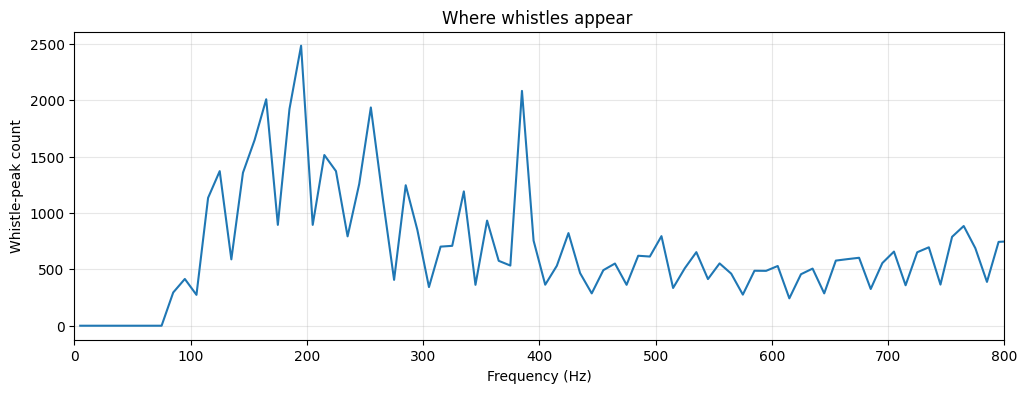

In [25]:
if len(all_freqs) == 0:
    print("No whistles found")
else:
    # histogram by frequencies
    bins = np.arange(0, 1500+10, 10)  # шаг 10 Гц
    hist, edges = np.histogram(all_freqs, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.figure(figsize=(12,4))
    plt.plot(centers, hist)
    plt.xlim(0, 800)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Whistle-peak count")
    plt.title("Where whistles appear ")
    plt.grid(alpha=0.3)
    plt.show()



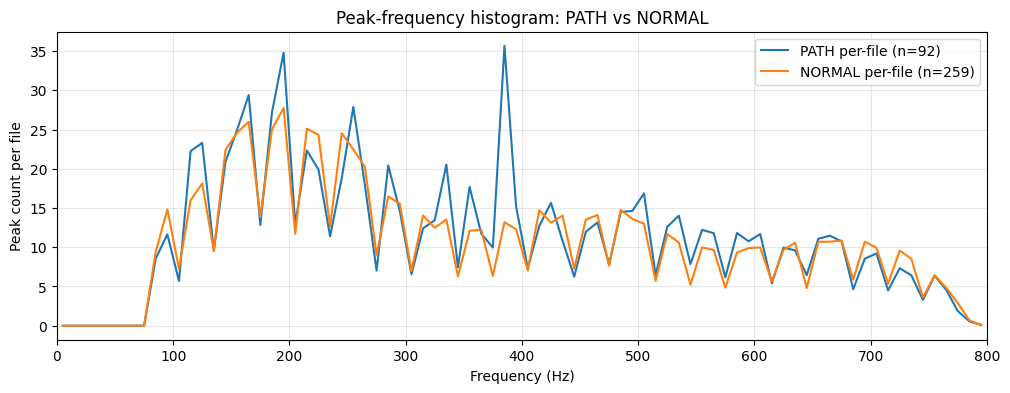

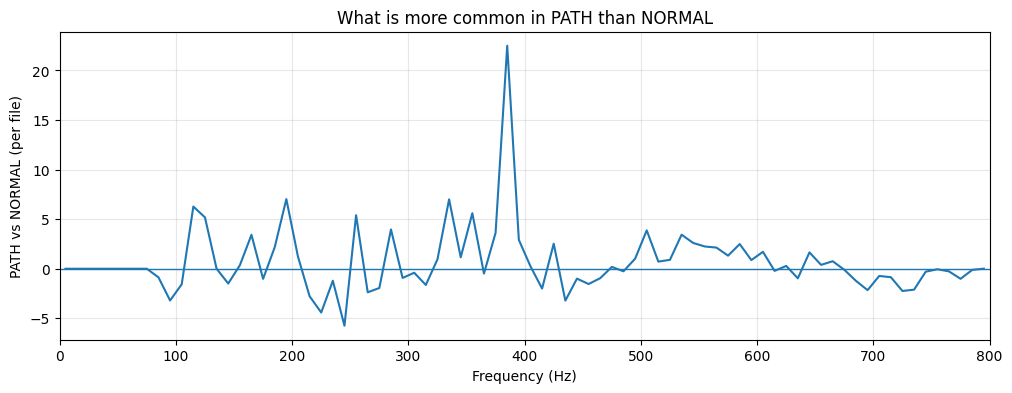

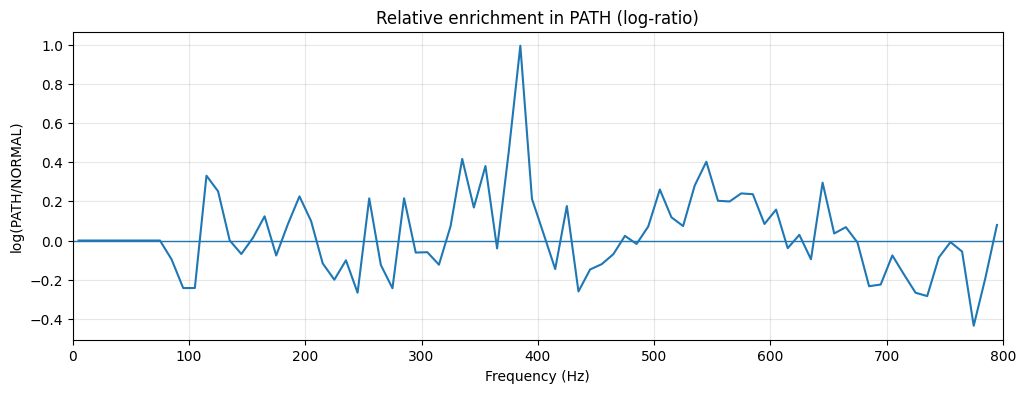

In [26]:
wavs = sorted(FOLDER.glob("*.wav"))
bins = np.arange(0, 800+10, 10)
centers = 0.5*(bins[:-1] + bins[1:])

path_counts, n_path = peak_hist_for_group(wavs, bins, label_map_merged, "path", min_prom_db=8.0, fmax=800)
norm_counts, n_norm = peak_hist_for_group(wavs, bins, label_map_merged, "normal", min_prom_db=8.0, fmax=800)

# normalize by the number of files to make the comparison fair
path_rate = path_counts / max(n_path, 1)
norm_rate = norm_counts / max(n_norm, 1)

diff = path_rate - norm_rate
log_ratio = np.log((path_rate + 1e-6) / (norm_rate + 1e-6))

plt.figure(figsize=(12,4))
plt.plot(centers, path_rate, label=f"PATH per-file (n={n_path})")
plt.plot(centers, norm_rate, label=f"NORMAL per-file (n={n_norm})")
plt.xlim(0, 800)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Peak count per file")
plt.title("Peak-frequency histogram: PATH vs NORMAL")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(f'Peak-frequency', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(centers, diff)
plt.axhline(0, linewidth=1)
plt.xlim(0, 800)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PATH vs NORMAL (per file)")
plt.title("What is more common in PATH than NORMAL")
plt.grid(alpha=0.3)
plt.savefig(f'Difference', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(centers, log_ratio)
plt.axhline(0, linewidth=1)
plt.xlim(0, 800)
plt.xlabel("Frequency (Hz)")
plt.ylabel("log(PATH/NORMAL)")
plt.title("Relative enrichment in PATH (log-ratio)")
plt.grid(alpha=0.3)
plt.show()

Normal: (259, 500), Path: (92, 500)


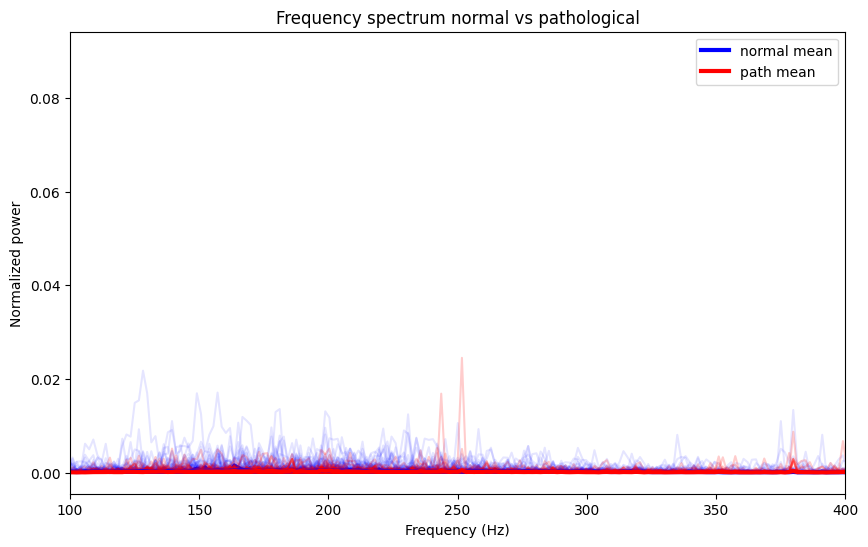

In [27]:
# spectrum for the whole fil

normal_specs = []
path_specs = []

for p in FOLDER.glob("*.wav"):
    if p.name not in label_map_merged:
        continue
    y, sr = sf.read(p)
    freqs, power = compute_spectrum(y, sr)
    power_interp = interpolate_spectrum(freqs, power, COMMON_FREQS)

    if label_map_merged[p.name] == "normal":
        normal_specs.append(power_interp)
    else:
        path_specs.append(power_interp)

normal_specs = np.array(normal_specs)
path_specs   = np.array(path_specs)

print(f"Normal: {normal_specs.shape}, Path: {path_specs.shape}")

plt.figure(figsize=(10, 6))

for s in normal_specs:
    plt.plot(COMMON_FREQS, s, color="blue", alpha=0.1)

for s in path_specs:
    plt.plot(COMMON_FREQS, s, color="red", alpha=0.2)

plt.plot(COMMON_FREQS, normal_specs.mean(axis=0),
         color="blue", linewidth=3, label="normal mean")
plt.plot(COMMON_FREQS, path_specs.mean(axis=0),
         color="red", linewidth=3, label="path mean")

plt.xlim(100, 400)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized power")
plt.title("Frequency spectrum normal vs pathological")
plt.legend()
plt.savefig('Frequency spectrum normal vs pathological.png', dpi=300, bbox_inches='tight')
plt.show()

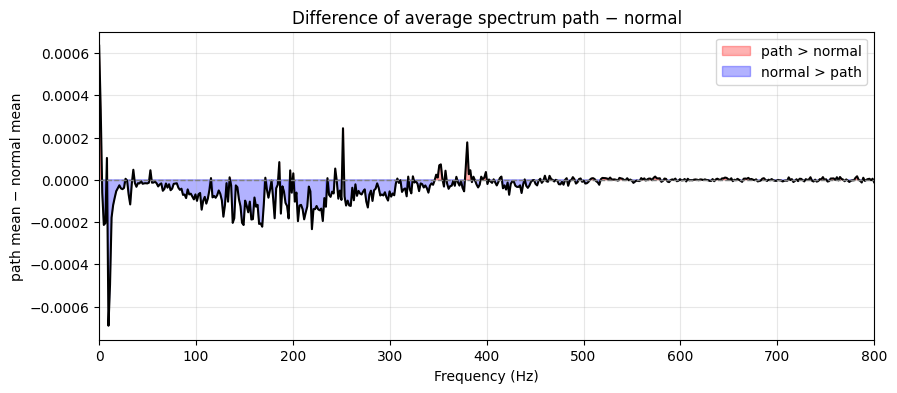

In [28]:
plt.figure(figsize=(10, 4))
diff_mean = path_specs.mean(axis=0) - normal_specs.mean(axis=0)
plt.plot(COMMON_FREQS, diff_mean, color="black", linewidth=1.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.fill_between(COMMON_FREQS, diff_mean, 0,
                 where=(diff_mean > 0), color="red", alpha=0.3, label="path > normal")
plt.fill_between(COMMON_FREQS, diff_mean, 0,
                 where=(diff_mean < 0), color="blue", alpha=0.3, label="normal > path")
plt.xlim(0, 800)
plt.xlabel("Frequency (Hz)")
plt.ylabel("path mean − normal mean")
plt.title("Difference of average spectrum path − normal")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##The averaged spectrum of the whole file is not a good feature to separate groups. This is logical, because pathology manifests itself in dynamics - peaks appear and disappear at certain moments, and not in the average over the entire recording.

* **file_band_presence** - for a single file, it calculates the proportion of time frames where there is a pronounced peak in the specified frequency band (band). Returns presence, the proportion of frames with a hit (from 0 to 1), the sampling frequency,

In [29]:
df_band = build_band_table(FOLDER, label_map_merged, band=(360, 390), min_prom_db=8.0, fmax=800)
display(df_band.sort_values("presence_360_390", ascending=False).head(5))

print("Mean presence by label:")
display(df_band.groupby("label")["presence_360_390"].describe())

top_path = (df_band[df_band["label"]=="path"].sort_values("presence_360_390", ascending=False).head(15))
display(top_path)

,filename,label,frames,presence_360_390,n_peaks_total
84,data1_rec63.wav,normal,71,0.971831,211
107,data1_rec87.wav,normal,162,0.901235,472
96,data1_rec77.wav,path,311,0.691318,905
247,data2_rec215.wav,path,367,0.689373,1074
265,data2_rec231.wav,path,367,0.662125,1076


Mean presence by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
normal,259.0,0.108354,0.083819,0.021739,0.079683,0.093220,0.122825,0.971831
path,92.0,0.174521,0.154982,0.021798,0.096821,0.125239,0.160714,0.691318


,filename,label,frames,presence_360_390,n_peaks_total
96,data1_rec77.wav,path,311,0.691318,905
247,data2_rec215.wav,path,367,0.689373,1074
265,data2_rec231.wav,path,367,0.662125,1076
224,data2_rec195.wav,path,367,0.656676,1068
212,data2_rec184.wav,path,367,0.653951,1083
234,data2_rec203.wav,path,367,0.653951,1077
194,data2_rec168.wav,path,367,0.585831,1064
108,data1_rec88.wav,path,51,0.529412,150
259,data2_rec226.wav,path,490,0.283673,1346
213,data2_rec185.wav,path,490,0.283673,1346


#Scan the entire spectrum in 30 Hz bands with a 10 Hz step

In [30]:

def scan_all_bands(label_map, folder,
                   band_width=30, step=10,
                   f_min=20, f_max=800,
                   nperseg=512, noverlap=384):
    records = {}
    for p in sorted(folder.glob("*.wav")):
        if p.name not in label_map:
            continue
        y, sr = sf.read(p)
        f, t, Sxx = compute_spectrogram(y, sr, nperseg=nperseg, noverlap=noverlap, to_db=False)
        records[p.name] = {
            "label": label_map[p.name],
            "f": f,
            "Sxx": Sxx
        }
    results = []
    bands = np.arange(f_min, f_max - band_width, step)

    for band_lo in bands:
        band_hi = band_lo + band_width
        powers = []
        labels = []

        for fname, rec in records.items():
            mask = (rec["f"] >= band_lo) & (rec["f"] <= band_hi)
            if mask.sum() == 0:
                continue
            power = float(rec["Sxx"][mask, :].mean())
            powers.append(power)
            labels.append(rec["label"])

        powers = np.array(powers)
        labels = np.array(labels)
        y_true = (labels == "path").astype(int)

        if y_true.sum() < 5 or (1-y_true).sum() < 5:
            continue

        fpr, tpr, _ = roc_curve(y_true, powers)
        roc_auc = auc(fpr, tpr)
        if roc_auc < 0.5:
            roc_auc = 1 - roc_auc

        _, pval = mannwhitneyu(
            powers[labels=="normal"],
            powers[labels=="path"],
            alternative="two-sided"
        )

        results.append({
            "band_lo": band_lo,
            "band_hi": band_hi,
            "band":    f"{int(band_lo)}-{int(band_hi)} Hz",
            "auc":     roc_auc,
            "pval":    pval,
            "mean_normal": float(powers[labels=="normal"].mean()),
            "mean_path":   float(powers[labels=="path"].mean()),
        })

    return pd.DataFrame(results).sort_values("auc", ascending=False)


df_scan = scan_all_bands(label_map_merged, FOLDER)
print("\nBest bands by AUC:")
print(df_scan.head(15).to_string(index=False))


Best bands by AUC:
 band_lo  band_hi       band      auc         pval  mean_normal  mean_path
     290      320 290-320 Hz 0.728387 7.569651e-11     0.000034   0.000018
     260      290 260-290 Hz 0.728345 7.630154e-11     0.000046   0.000024
     270      300 270-300 Hz 0.727631 8.734060e-11     0.000041   0.000021
     280      310 280-310 Hz 0.727380 9.159796e-11     0.000038   0.000020
     300      330 300-330 Hz 0.717937 5.262541e-10     0.000030   0.000017
     310      340 310-340 Hz 0.717098 6.126337e-10     0.000028   0.000016
     250      280 250-280 Hz 0.716216 7.181996e-10     0.000052   0.000027
     240      270 240-270 Hz 0.714621 9.560965e-10     0.000055   0.000029
     220      250 220-250 Hz 0.711894 1.552438e-09     0.000061   0.000033
     230      260 230-260 Hz 0.711348 1.709264e-09     0.000059   0.000032
     320      350 320-350 Hz 0.706816 3.767609e-09     0.000026   0.000015
     410      440 410-440 Hz 0.700227 1.154661e-08     0.000014   0.000007
     

In [31]:
def band_metrics(label_map, band=(360, 390),
                 nperseg=512, noverlap=384,
                 min_prom_db=MIN_PROM_DB):
    """
 For each file, it calculates:
 - presence : the fraction of frames that have a peak in the range
 - freq_mean : the average frequency of the peaks
 - freq_std : the stability of the frequency (small = stable whistle)
 - strength_mean : the average prominence of the peaks (loudness)
 - n_peaks : the total number of peaks in the range
  """
    rows = []
    for p in sorted(FOLDER.glob("*.wav")):
        if p.name not in label_map:
            continue

        y, sr = sf.read(p)
        f, t, Sxx_db = compute_spectrogram(y, sr, nperseg=nperseg, noverlap=noverlap)

        band_lo, band_hi = band
        fb_mask = (f >= 0) & (f <= 800)
        fb = f[fb_mask]
        Sb = Sxx_db[fb_mask, :]

        hit_freqs, hit_strengths = [], []
        total_frames = Sb.shape[1]

        for j in range(total_frames):
            col = Sb[:, j]
            peaks, props = find_peaks(col, prominence=min_prom_db)
            for idx, pk in enumerate(peaks):
                fr = fb[pk]
                if band_lo <= fr <= band_hi:
                    hit_freqs.append(fr)
                    hit_strengths.append(props["prominences"][idx])

        n = len(hit_freqs)
        rows.append({
            "filename":     p.name,
            "label":        label_map[p.name],
            "presence":     n / total_frames,
            "freq_mean":    np.mean(hit_freqs)    if n else np.nan,
            "freq_std":     np.std(hit_freqs)     if n else np.nan,
            "strength_mean":np.mean(hit_strengths) if n else np.nan,
            "n_peaks":      n,
        })

    return pd.DataFrame(rows)


#What is the Mann-Whitney U test?
It is a statistical test that allows you to determine whether the difference between two groups is random. It combines all the values into a single list, sorts them, assigns a rank to each value, calculates the number of normal values that are less than the pathological value for each pathological value, and then calculates the p-value. The p-value represents the probability that the number of normal files is simply random. The Bonferroni correction is needed because the 360-390 Hz band was selected from 75 candidates using scan_all_bands. If you test many hypotheses in a row, some of them will be significant just by chance, so the threshold is divided by the number of tests: instead of p < 0.05, we use p < 0.05/75 = 0.00067, which makes the evaluation fair.

 Метрики по группам 


presence                                                  freq_mean  \
          count   mean    std    min    25%    50%    75%    max     count   
label                                                                        
normal    259.0  0.572  0.083  0.244  0.542  0.574  0.601  1.043     259.0   
path       92.0  0.617  0.127  0.398  0.552  0.593  0.647  0.989      92.0   

                 ... strength_mean         n_peaks                         \
           mean  ...           75%     max   count     mean     std   min   
label            ...                                                        
normal  374.930  ...        15.078  34.347   259.0  172.730  76.901  13.0   
path    376.268  ...        16.593  26.670    92.0  201.598  79.190  30.0   

                                     
           25%    50%    75%    max  
label                                
normal  129.00  185.0  223.0  382.0  
path    155.75  197.5  245.0  363.0  

[2 rows x 40 columns]

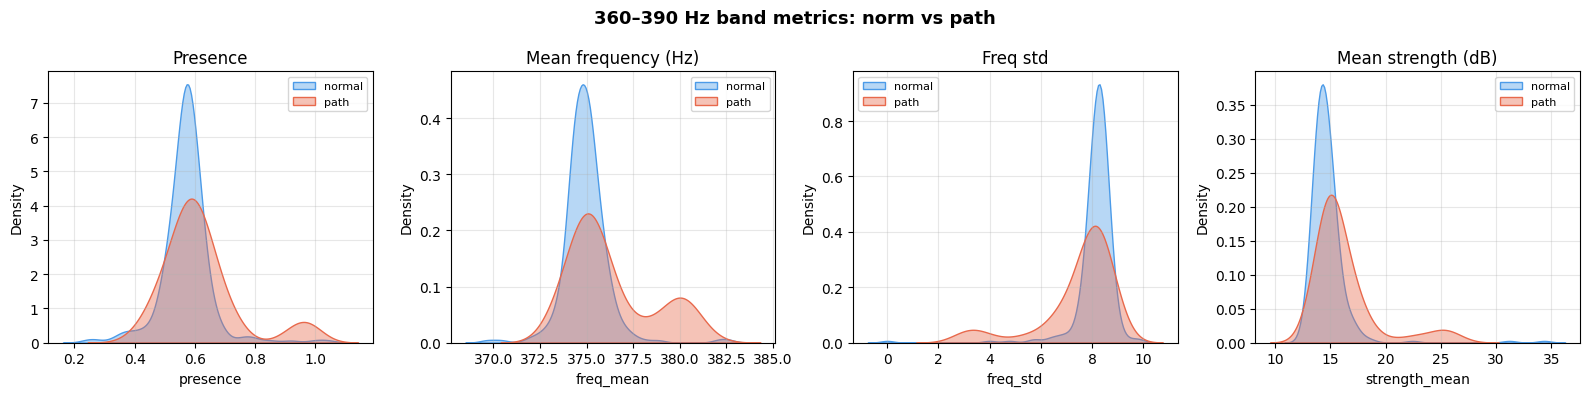

presence            : p = 0.0034
freq_mean           : p = 0.0000
freq_std            : p = 0.0000
strength_mean       : p = 0.0000


In [32]:
df_metrics = band_metrics(label_map_merged, band=(360, 390))

print(" Метрики по группам ")
display(df_metrics.groupby("label")[
    ["presence", "freq_mean", "freq_std", "strength_mean", "n_peaks"]
].describe().round(3))

# Визуализация
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col, title in zip(axes,
    ["presence", "freq_mean", "freq_std", "strength_mean"],
    ["Presence", "Mean frequency (Hz)",
     "Freq std", "Mean strength (dB)"]):

    for lbl, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
        vals = df_metrics[df_metrics["label"] == lbl][col].dropna()
        sns.kdeplot(vals, ax=ax, color=color, fill=True,
                    alpha=0.4, label=lbl)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("360–390 Hz band metrics: norm vs path",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("band_metrics_kde.png", dpi=150, bbox_inches="tight")
plt.show()

n_bands = len(df_scan)
alpha = 0.05
alpha_corrected = alpha / n_bands



for col in ["presence", "freq_mean", "freq_std", "strength_mean"]:
    n = df_metrics[df_metrics["label"]=="normal"][col].dropna()
    p = df_metrics[df_metrics["label"]=="path"][col].dropna()
    _, pval = mannwhitneyu(n, p, alternative="two-sided")
    print(f"{col:20s}: p = {pval:.4f}")

        count      mean       std       min       25%       50%       75%  \
label                                                                       
normal  259.0  0.870317  0.054076  0.476197  0.863457  0.882614  0.899330   
path     92.0  0.866324  0.069839  0.630424  0.854425  0.878980  0.906998   

             max  
label             
normal  0.946003  
path    0.948004  


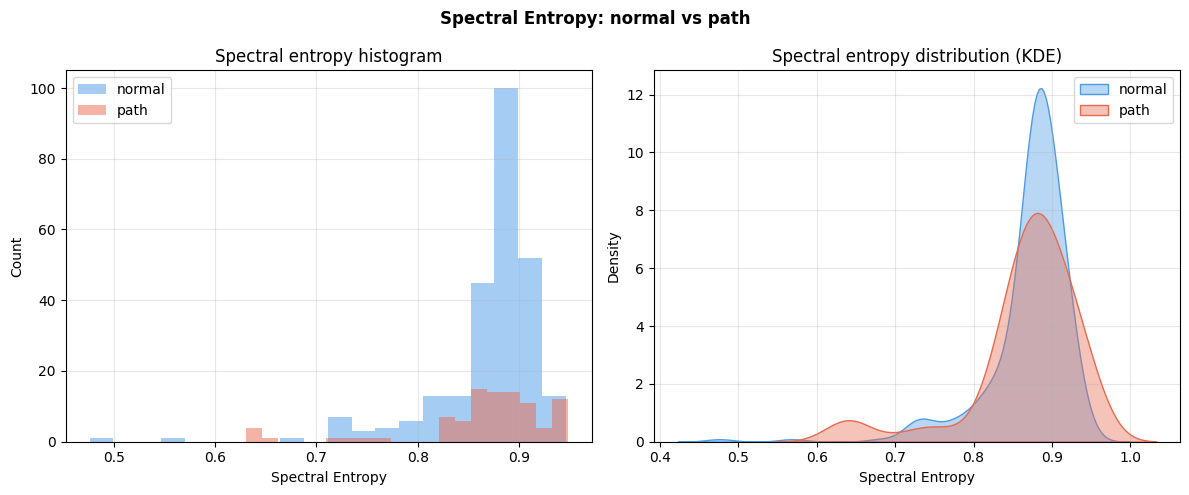

In [33]:
#Spectral features

df_spectral = compute_spectral_features_for_folder(FOLDER, label_map_merged)

print(df_spectral.groupby('label')['spectral_entropy'].describe())


# Vizualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# histogram
ax = axes[0]
for lab, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
    vals = df_spectral[df_spectral["label"]==lab]["spectral_entropy"]
    ax.hist(vals, bins=20, alpha=0.5, color=color, label=lab)
ax.legend()
ax.set_xlabel("Spectral Entropy")
ax.set_ylabel("Count")
ax.set_title("Spectral entropy histogram")
ax.grid(alpha=0.3)

# KDE
ax = axes[1]
for lab, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
    vals = df_spectral[df_spectral["label"]==lab]["spectral_entropy"]
    sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.4, label=lab)
ax.legend()
ax.set_xlabel("Spectral Entropy")
ax.set_title("Spectral entropy distribution (KDE)")
ax.grid(alpha=0.3)

plt.suptitle("Spectral Entropy: normal vs path", fontweight="bold")
plt.tight_layout()
plt.savefig("spectral_entropy.png", dpi=300, bbox_inches="tight")
plt.show()

#Wavelet Entropy

Файлов: 351
   wavelet_entropy_level_0  wavelet_entropy_level_1  wavelet_entropy_level_2  \
0                 0.689498                 0.808272                 0.848555   
1                 0.876669                 0.868787                 0.863732   
2                 0.902676                 0.890729                 0.901771   
3                 0.774218                 0.861890                 0.835683   
4                 0.775182                 0.868444                 0.868562   

   wavelet_entropy_level_3  wavelet_entropy_level_4  wavelet_entropy_level_5  \
0                 0.866690                 0.880201                 0.822702   
1                 0.869543                 0.862434                 0.864013   
2                 0.904556                 0.895309                 0.888935   
3                 0.786847                 0.779030                 0.785169   
4                 0.871601                 0.875480                 0.864946   

           filename   labe

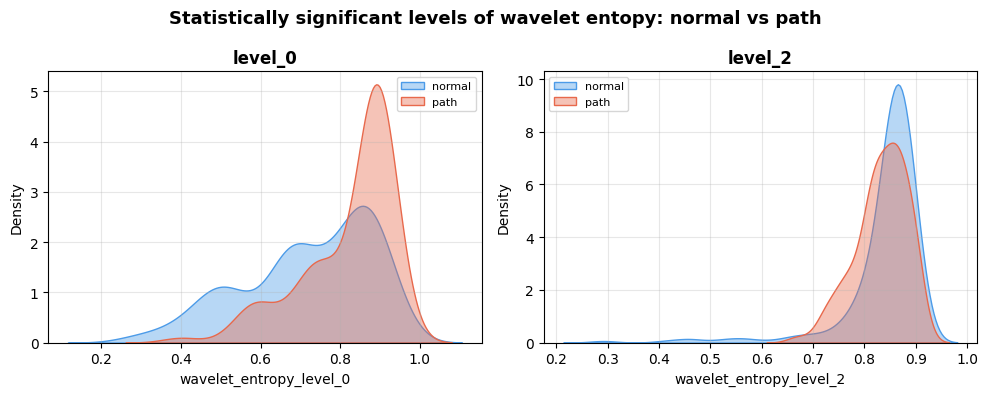

In [34]:

# Compute for all files
rows_wav = []
for p in sorted(FOLDER.glob("*.wav")):
    if p.name not in label_map_merged:
        continue
    y, sr = sf.read(p)
    y = np.asarray(y).reshape(-1)

    feats = compute_wavelet_entropy(y, sr)
    feats["filename"] = p.name
    feats["label"] = label_map_merged[p.name]
    rows_wav.append(feats)

df_wavelet = pd.DataFrame(rows_wav)
print(f"Файлов: {len(df_wavelet)}")
print(df_wavelet.head())

# Mann-Whitney
wavelet_cols = [c for c in df_wavelet.columns if c.startswith("wavelet_entropy")]
alpha_corrected = 0.05 / len(wavelet_cols)

print(f"\nMann-Whitney U (Bonferoni correction: p < {alpha_corrected:.4f})")
for col in wavelet_cols:
    n = df_wavelet[df_wavelet["label"]=="normal"][col].dropna()
    p = df_wavelet[df_wavelet["label"]=="path"][col].dropna()
    _, pval = mannwhitneyu(n, p, alternative="two-sided")
    print(f"{col:30s}: p = {pval:.4f}")

# Vizualization only statistically significant ones
sig_cols = [c for c in wavelet_cols
            if mannwhitneyu(
                df_wavelet[df_wavelet["label"]=="normal"][c].dropna(),
                df_wavelet[df_wavelet["label"]=="path"][c].dropna(),
                alternative="two-sided"
            )[1] < alpha_corrected]

if sig_cols:
    fig, axes = plt.subplots(1, len(sig_cols), figsize=(5*len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, sig_cols):
        for lab, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
            vals = df_wavelet[df_wavelet["label"]==lab][col].dropna()
            sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.4, label=lab)
        ax.set_title(col.replace("wavelet_entropy_", ""), fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle("Statistically significant levels of wavelet entopy: normal vs path",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("wavelet_entropy.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Error")

In [35]:
wavelet_results = []

for col in wavelet_cols:
    normal_vals = df_wavelet[df_wavelet["label"] == "normal"][col].dropna()
    path_vals = df_wavelet[df_wavelet["label"] == "path"][col].dropna()

    stat, pval = mannwhitneyu(
        normal_vals,
        path_vals,
        alternative="two-sided"
    )

    mean_normal = normal_vals.mean()
    mean_path = path_vals.mean()

    median_normal = normal_vals.median()
    median_path = path_vals.median()

    if mean_path > mean_normal:
        higher_group = "path"
    else:
        higher_group = "normal"

    wavelet_results.append({
        "feature": col,
        "p_value": pval,
        "significant": pval < alpha_corrected,
        "mean_normal": mean_normal,
        "mean_path": mean_path,
        "median_normal": median_normal,
        "median_path": median_path,
        "higher_mean": higher_group,
        "diff_path_minus_normal": mean_path - mean_normal
    })

df_wavelet_results = (
    pd.DataFrame(wavelet_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

display(df_wavelet_results)

,feature,p_value,significant,mean_normal,mean_path,median_normal,median_path,higher_mean,diff_path_minus_normal
0,wavelet_entropy_level_0,3.165174e-09,True,0.720640,0.821127,0.750927,0.877228,path,0.100487
1,wavelet_entropy_level_2,6.147508e-03,True,0.838684,0.832125,0.857158,0.840427,normal,-0.006559
2,wavelet_entropy_level_3,1.715579e-02,False,0.845907,0.824676,0.859020,0.851972,normal,-0.021231
3,wavelet_entropy_level_1,4.291838e-02,False,0.825828,0.851083,0.852406,0.860670,path,0.025255
4,wavelet_entropy_level_4,5.540931e-02,False,0.854077,0.836867,0.863724,0.853609,normal,-0.017210
5,wavelet_entropy_level_5,7.116710e-02,False,0.853091,0.832147,0.864677,0.857015,normal,-0.020943


In [36]:
target_wavelet_cols = [
    "wavelet_entropy_level_0",
    "wavelet_entropy_level_2"
]

y_true = (df_wavelet["label"] == "path").astype(int).values

wavelet_auc_results = []

print("ROC AUC for selected wavelet entropy features")
print("\n " )

for col in target_wavelet_cols:
    scores = df_wavelet[col].values
    mask = ~np.isnan(scores)

    fpr, tpr, _ = roc_curve(y_true[mask], scores[mask])
    roc_auc = auc(fpr, tpr)
    if roc_auc < 0.5:
        fpr, tpr, _ = roc_curve(y_true[mask], -scores[mask])
        roc_auc = auc(fpr, tpr)

    wavelet_auc_results.append({
        "feature": col,
        "auc": roc_auc
    })

    print(f"{col:30s}: AUC = {roc_auc:.3f}")

df_wavelet_auc = pd.DataFrame(wavelet_auc_results)
display(df_wavelet_auc)

ROC AUC for selected wavelet entropy features

 
wavelet_entropy_level_0       : AUC = 0.708
wavelet_entropy_level_2       : AUC = 0.596


,feature,auc
0,wavelet_entropy_level_0,0.707823
1,wavelet_entropy_level_2,0.596147


15 top features:


,feature,p_value,effect_size
0,mfcc_mean_4,1.384468e-07,0.369649
1,mfcc_mean_6,4.832420e-07,0.353198
2,mfcc_mean_0,4.351246e-06,0.322394
3,mfcc_std_0,7.332142e-06,0.314672
4,mfcc_std_2,5.130417e-05,0.284203
5,mfcc_mean_9,9.288715e-05,0.274299
6,mfcc_mean_8,9.381108e-05,0.274131
7,band_25_50,2.257005e-04,0.258855
8,mfcc_std_11,3.054734e-04,0.253399
9,mfcc_std_10,4.018834e-04,0.248363


Bonferroni correction: p < 0.00125


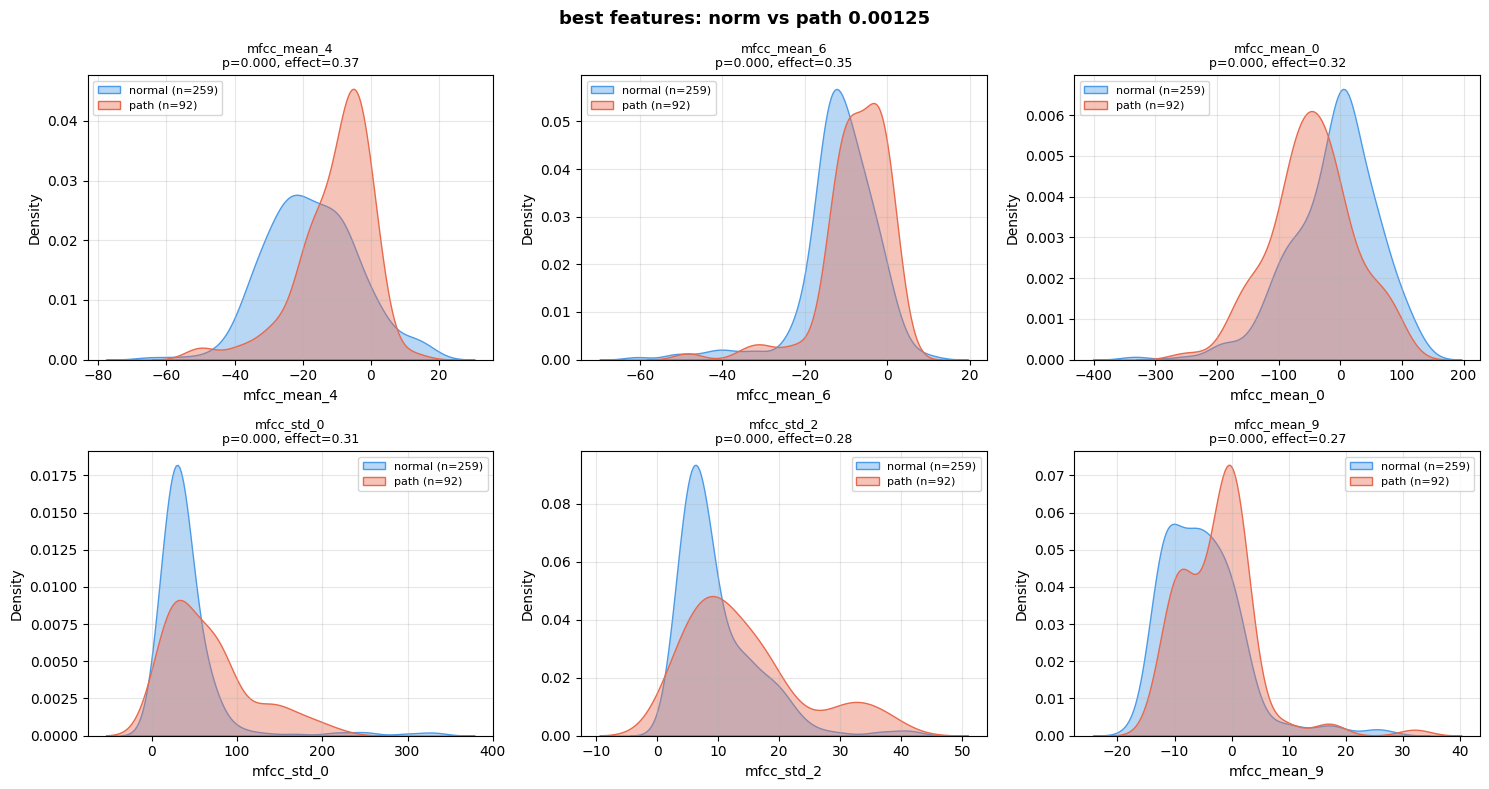

In [37]:
mfcc_rows = []
for p in sorted(FOLDER.glob("*.wav")):
    if p.name not in label_map_merged:
        continue
    y, sr = librosa.load(str(p), sr=SR, mono=True)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    row = {"filename": p.name}
    for i in range(13):
        row[f"mfcc_mean_{i}"] = mfcc[i].mean()
        row[f"mfcc_std_{i}"]  = mfcc[i].std()
    mfcc_rows.append(row)

df_mfcc = pd.DataFrame(mfcc_rows)
df_all = df_spectral.merge(df_mfcc, on="filename")


feat_cols = [c for c in df_all.columns
             if c not in ("filename", "label", "sr", "duration_sec")]

results = []
for feat in feat_cols:
    norm_v = df_all[df_all["label"] == "normal"][feat].dropna()
    path_v = df_all[df_all["label"] == "path"][feat].dropna()
    _, p = mannwhitneyu(norm_v, path_v, alternative="two-sided")
    # Effect size: rank-biserial correlation
    n1, n2 = len(norm_v), len(path_v)
    u, _ = mannwhitneyu(norm_v, path_v, alternative="two-sided")
    rbc = 1 - (2 * u) / (n1 * n2)
    results.append({"feature": feat, "p_value": p, "effect_size": abs(rbc)})

df_pval = (pd.DataFrame(results)
           .sort_values("effect_size", ascending=False)
           .reset_index(drop=True))

print("15 top features:")
display(df_pval.head(15))

alpha_corrected = 0.05 / len(feat_cols)
print(f"Bonferroni correction: p < {alpha_corrected:.5f}")

top_feats = df_pval[df_pval["p_value"] < alpha_corrected]["feature"].tolist()[:6]

if top_feats:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for ax, feat in zip(axes, top_feats):
        for lbl, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
            sub = df_all[df_all["label"] == lbl][feat].dropna()
            sns.kdeplot(sub, ax=ax, color=color, fill=True, alpha=0.4,
                        label=f"{lbl} (n={len(sub)})")
        p_val = df_pval[df_pval["feature"] == feat]["p_value"].values[0]
        eff   = df_pval[df_pval["feature"] == feat]["effect_size"].values[0]
        ax.set_title(f"{feat}\np={p_val:.3f}, effect={eff:.2f}", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle(f"best features: norm vs path {alpha_corrected}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("top_features_kde.png", dpi=150, bbox_inches="tight")
    plt.show()


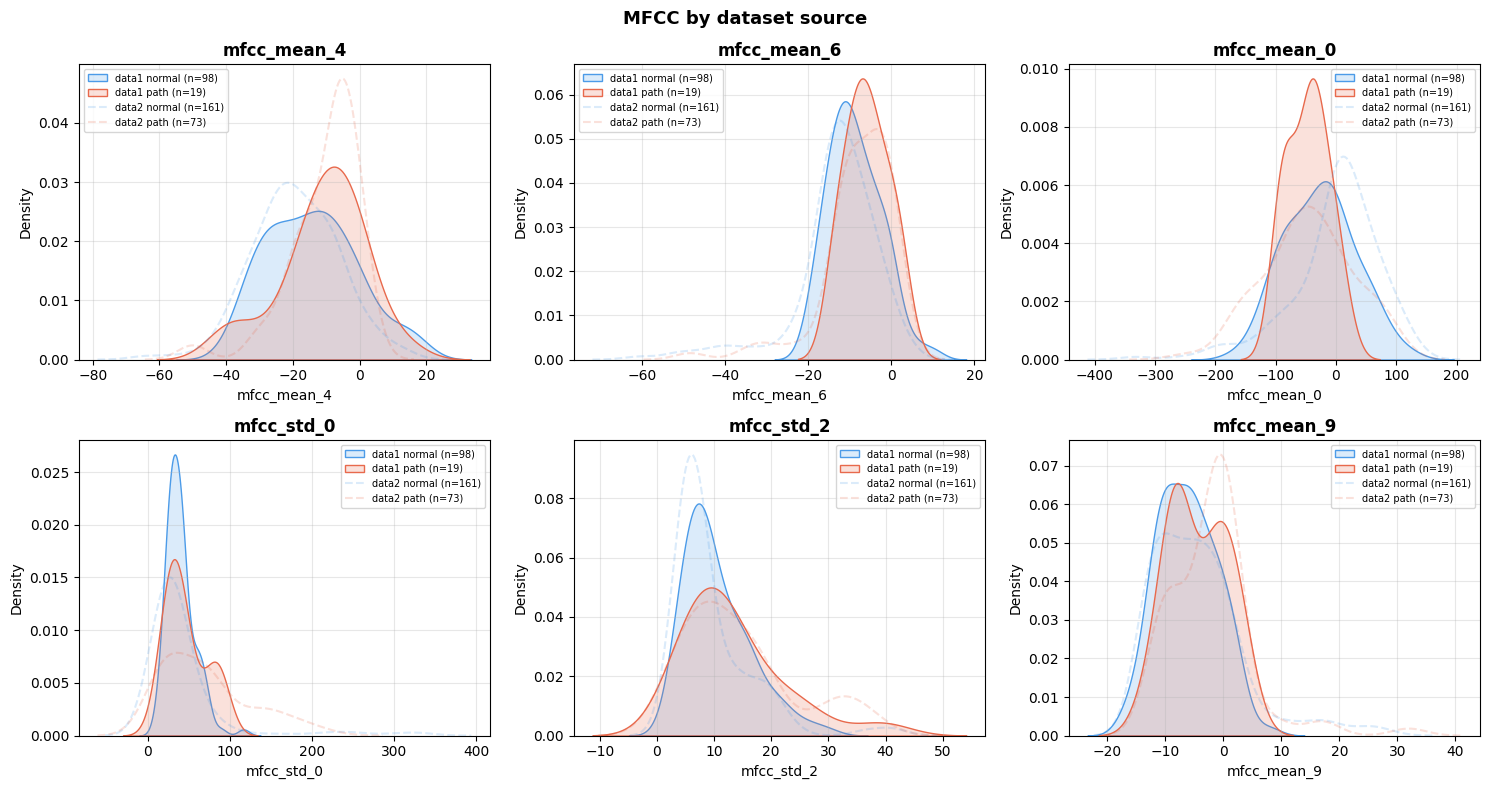

Average values of MFCC by source:

mfcc_mean_4:
filename  label 
data1     normal   -14.280000
          path     -11.080000
data2     normal   -19.290001
          path     -10.440000
Name: mfcc_mean_4, dtype: float32

mfcc_mean_6:
filename  label 
data1     normal    -8.78
          path      -5.86
data2     normal   -13.24
          path      -8.00
Name: mfcc_mean_6, dtype: float32

mfcc_mean_0:
filename  label 
data1     normal   -26.969999
          path     -47.060001
data2     normal    -0.840000
          path     -45.799999
Name: mfcc_mean_0, dtype: float32

mfcc_std_0:
filename  label 
data1     normal    39.570000
          path      46.020000
data2     normal    43.480000
          path      70.870003
Name: mfcc_std_0, dtype: float32

mfcc_std_2:
filename  label 
data1     normal    10.55
          path      13.35
data2     normal     9.46
          path      14.43
Name: mfcc_std_2, dtype: float32

mfcc_mean_9:
filename  label 
data1     normal   -6.21
          path     -4

In [38]:
# check metrics by datasets
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_feats):
    for source, ls in [("data1", "-"), ("data2", "--")]:
        for lab, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
            vals = df_all[
                (df_all["filename"].str.startswith(source)) &
                (df_all["label"] == lab)
            ][feat]
            if len(vals) > 3:
                sns.kdeplot(vals, ax=ax, color=color, linestyle=ls,
                           fill=(ls=="-"), alpha=0.2,
                           label=f"{source} {lab} (n={len(vals)})")
    ax.set_title(feat, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("MFCC by dataset source",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mfcc_by_source.png", dpi=300, bbox_inches="tight")
plt.show()

print("Average values of MFCC by source:")
for feat in top_feats:
    print(f"\n{feat}:")
    print(df_all.groupby([
        df_all["filename"].str[:5], "label"
    ])[feat].mean().round(2))

**reliable** : mfcc_mean_4, mfcc_mean_6, mfcc_std_2, mfcc_mean_9, mfcc_std_0

**bad** : mfcc_mean_0 - the direction is the same, but data2 normal = -0.8 vs data1 normal = -27 - a huge difference between the datasets of normal records. This suggests that mfcc_mean_0 is highly dependent on the source of the record, rather than just on pathology. The model can use it to distinguish between datasets, not diseases.

Reliable MFCC: ['mfcc_mean_4', 'mfcc_mean_6', 'mfcc_std_0', 'mfcc_std_2']
AUC for stat significant MFCC features:


  mfcc_mean_4    : AUC=0.685, p=0.0000
  mfcc_mean_6    : AUC=0.677, p=0.0000
  mfcc_std_0     : AUC=0.657, p=0.0000
  mfcc_std_2     : AUC=0.642, p=0.0001


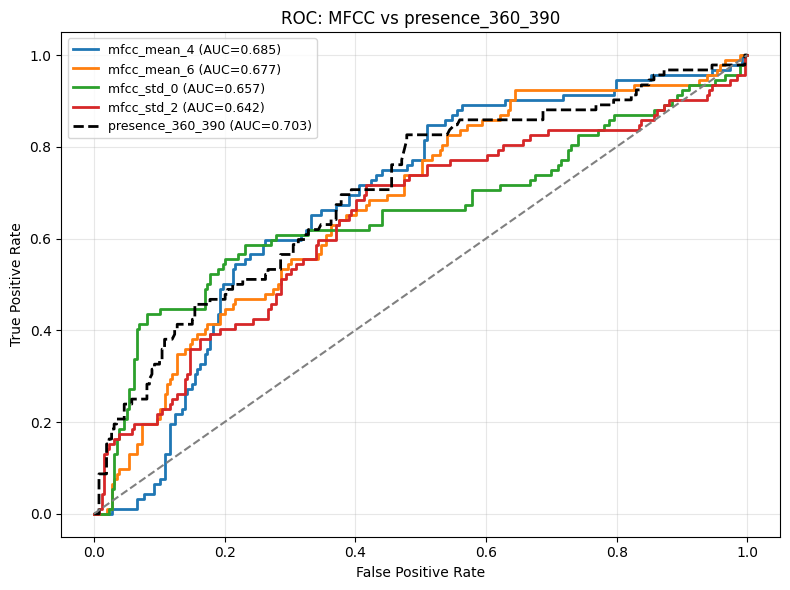

In [40]:

reliable_mfcc = [f for f in top_feats if f != "mfcc_mean_0"][:4]
print("Reliable MFCC:", reliable_mfcc)
y_true = (df_all["label"] == "path").astype(int).values

plt.figure(figsize=(8, 6))
print("AUC for stat significant MFCC features:")
print("\n" )

for feat in reliable_mfcc:
    scores = df_all[feat].values
    mask = ~np.isnan(scores)

    fpr, tpr, _ = roc_curve(y_true[mask], scores[mask])
    roc_auc = auc(fpr, tpr)
    if roc_auc < 0.5:
        fpr, tpr, _ = roc_curve(y_true[mask], -scores[mask])
        roc_auc = auc(fpr, tpr)

    _, pval = mannwhitneyu(
        df_all[df_all["label"]=="normal"][feat].dropna(),
        df_all[df_all["label"]=="path"][feat].dropna(),
        alternative="two-sided"
    )

    print(f"  {feat:15s}: AUC={roc_auc:.3f}, p={pval:.4f}")
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{feat} (AUC={roc_auc:.3f})")

fpr_p, tpr_p, _ = roc_curve(
    (df_band["label"]=="path").astype(int).values,
    df_band["presence_360_390"].values
)
plt.plot(fpr_p, tpr_p, linewidth=2, linestyle="--",
         color="black", label="presence_360_390 (AUC=0.703)")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: MFCC vs presence_360_390")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_mfcc_reliable.png", dpi=300, bbox_inches="tight")
plt.show()

Pathological: 92
Normal: 259


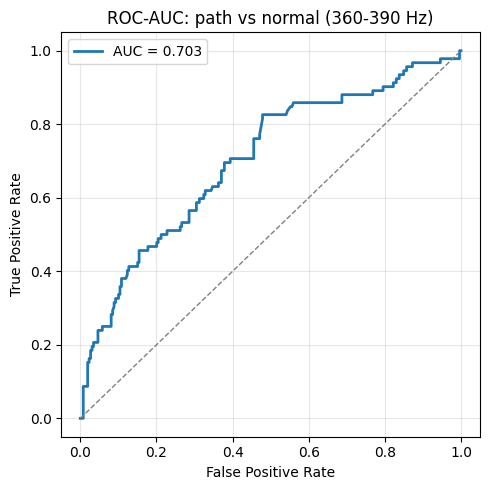

AUC = 0.7032272956186001


In [41]:
#presence ROC AUC

# target: 1 = path, 0 = normal
y_true = (df_band["label"] == "path").astype(int).values
scores = df_band["presence_360_390"].values

print("Pathological:", y_true.sum())
print("Normal:", (1 - y_true).sum())

# ROC
fpr, tpr, thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC: path vs normal (360-390 Hz)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("AUC-ROC", dpi=300, bbox_inches="tight")
plt.show()

print("AUC =", roc_auc)

df_irreg готов: 351 файлов
label
normal    259
path       92
Name: count, dtype: int64

Mann-Whitney U (Bonferroni correction: p < 0.0083)
cv_interval         : p = 0.0456
mean_interval       : p = 0.1041
on_duration_mean    : p = 0.0001
on_duration_std     : p = 0.0003
presence_mean       : p = 0.0002
presence_std        : p = 0.0000


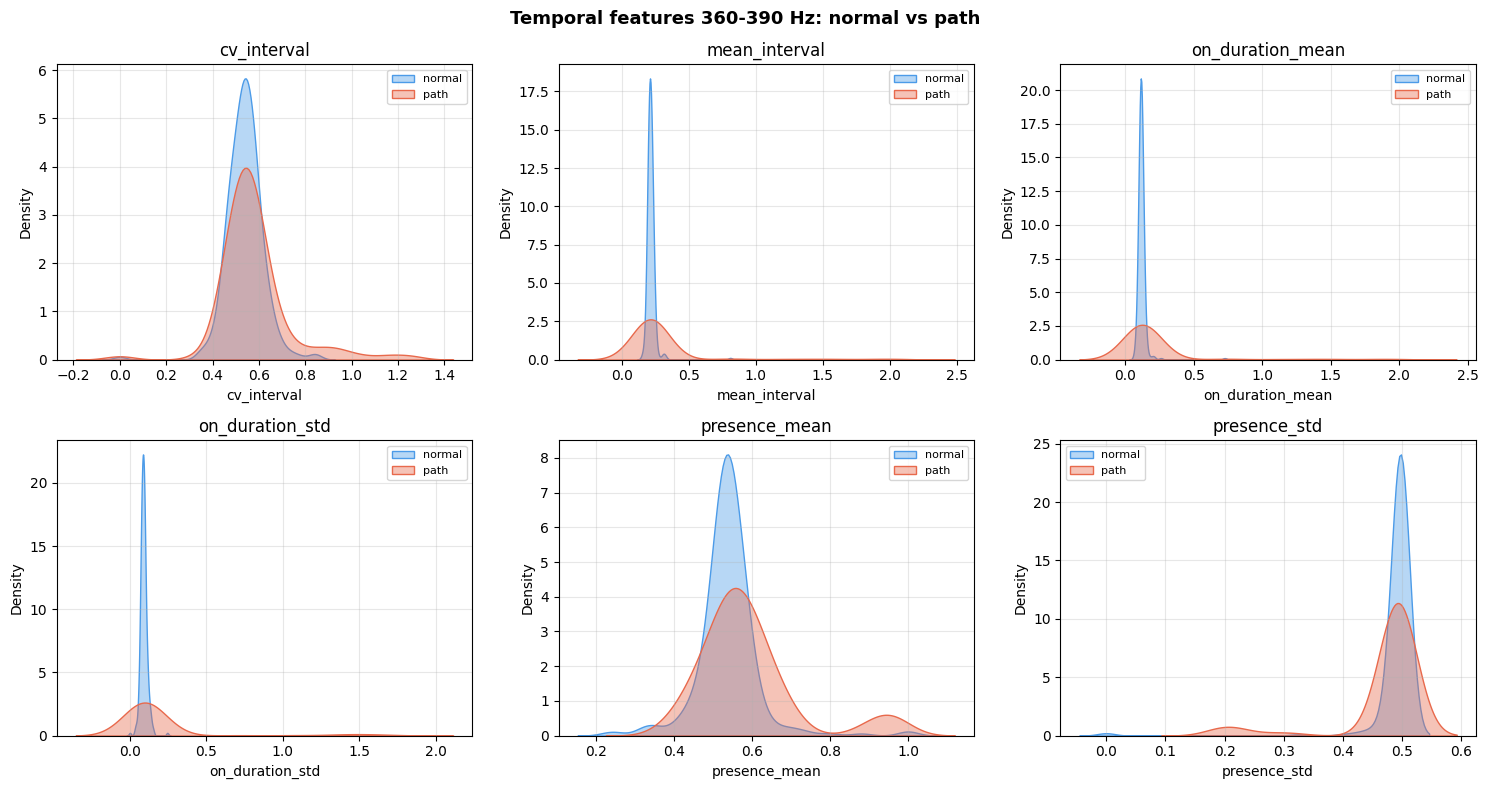

In [42]:
# Irregularities for all files
rows_irreg = []
for p in sorted(FOLDER.glob("*.wav")):
    fname = p.name
    if fname not in label_map_merged:
        continue
    metrics = estimate_pulse_irregularity(str(p))
    metrics["filename"] = fname
    metrics["label"]    = label_map_merged[fname]
    metrics["source"]   = "data1" if fname.startswith("data1_") else "data2"
    rows_irreg.append(metrics)

df_irreg = pd.DataFrame(rows_irreg)
print(f"df_irreg готов: {len(df_irreg)} файлов")
print(df_irreg["label"].value_counts())

# Mann-Whitney
n_metrics = 6
alpha_corrected = 0.05 / n_metrics
print(f"\nMann-Whitney U (Bonferroni correction: p < {alpha_corrected:.4f})")
for col in ["cv_interval", "mean_interval", "on_duration_mean", "on_duration_std", "presence_mean", "presence_std"]:
    norm = df_irreg[df_irreg["label"]=="normal"][col].dropna()
    path = df_irreg[df_irreg["label"]=="path"][col].dropna()
    _, pval = mannwhitneyu(norm, path, alternative="two-sided")
    print(f"{col:20s}: p = {pval:.4f}")

# Vizualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, ["cv_interval", "mean_interval", "on_duration_mean",
                           "on_duration_std", "presence_mean", "presence_std"]):
    for lab, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
        vals = df_irreg[df_irreg["label"]==lab][col].dropna()
        sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.4, label=lab)
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Temporal features 360-390 Hz: normal vs path", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("irregularity_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

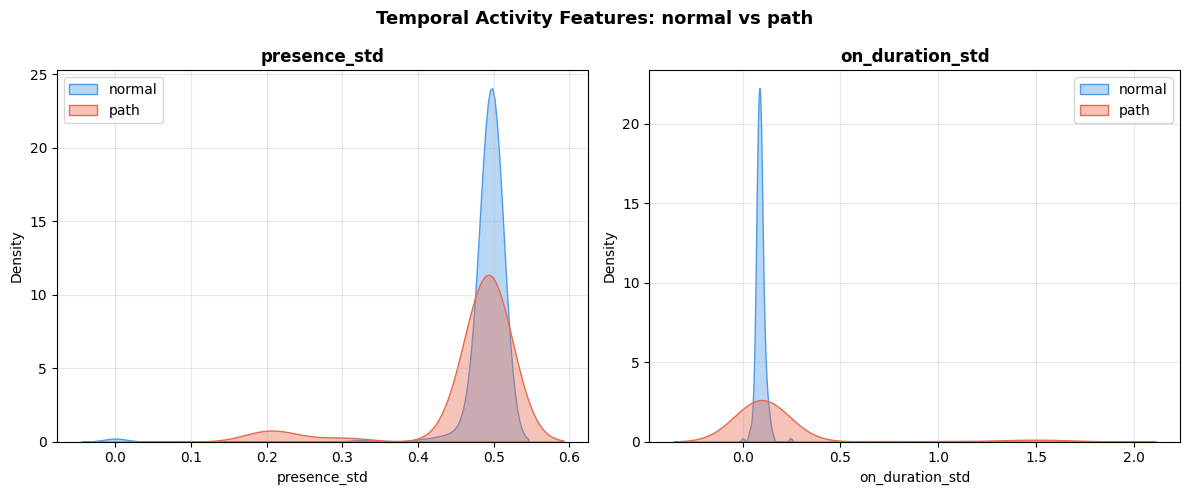

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ["presence_std", "on_duration_std"]):
    for lab, color in [("normal", "#4C9BE8"), ("path", "#E8694C")]:
        vals = df_irreg[df_irreg["label"] == lab][col].dropna()
        sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.4, label=lab)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Temporal Activity Features: normal vs path",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("temporal_features.png", dpi=300, bbox_inches="tight")
plt.show()

ROC AUC for markers:


  presence_360_390    : AUC = 0.703
  mfcc_mean_4         : AUC = 0.685
  mfcc_mean_6         : AUC = 0.677
  on_duration_std     : AUC = 0.628
  presence_std        : AUC = 0.657
  mfcc_std_2          : AUC = 0.642
  mfcc_mean_9         : AUC = 0.637


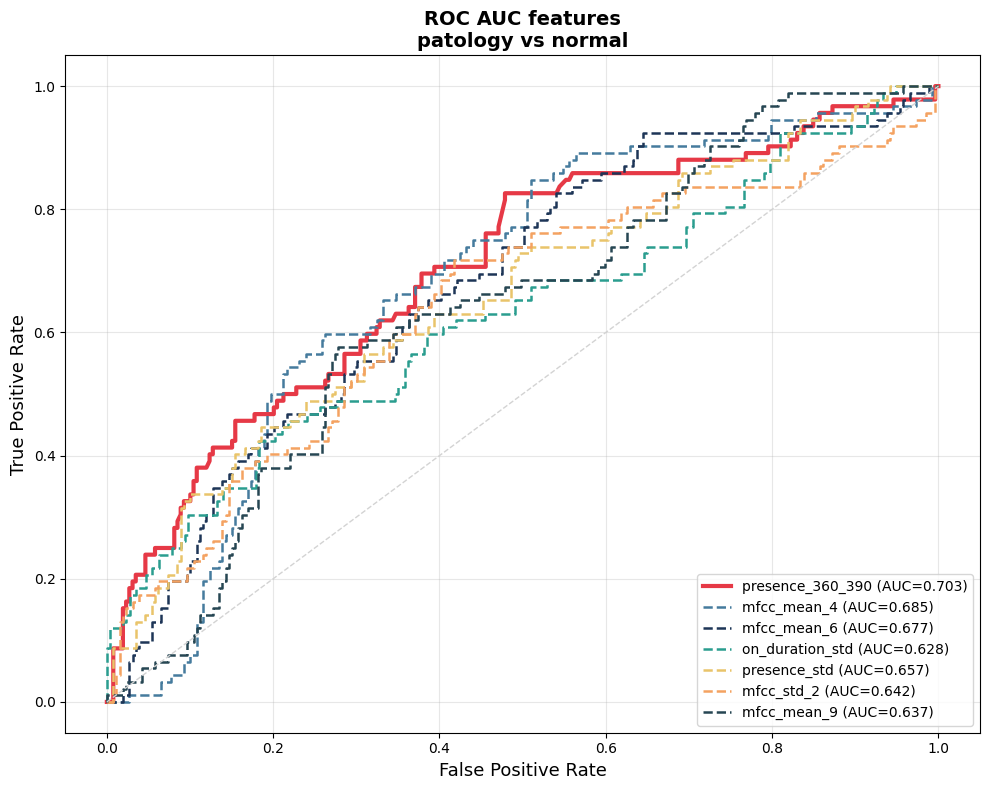

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))

# All markers
markers = [
    ("presence_360_390",  df_band["presence_360_390"].values,  df_band),
    ("mfcc_mean_4",       df_all["mfcc_mean_4"].values,        df_all),
    ("mfcc_mean_6",       df_all["mfcc_mean_6"].values,        df_all),
    ("on_duration_std",   df_irreg["on_duration_std"].values,   df_irreg),
    ("presence_std",      df_irreg["presence_std"].values,      df_irreg),
    ("mfcc_std_2",        df_all["mfcc_std_2"].values,          df_all),
    ("mfcc_mean_9",       df_all["mfcc_mean_9"].values,         df_all),
]

colors = ["#E63946", "#457B9D", "#1D3557", "#2A9D8F",
          "#E9C46A", "#F4A261", "#264653", "#6A4C93"]

print("ROC AUC for markers:")
print("\n")

for (name, scores, df), color in zip(markers, colors):
    y_true = (df["label"] == "path").astype(int).values
    mask = ~np.isnan(scores)

    fpr, tpr, _ = roc_curve(y_true[mask], scores[mask])
    roc_auc = auc(fpr, tpr)
    if roc_auc < 0.5:
        fpr, tpr, _ = roc_curve(y_true[mask], -scores[mask])
        roc_auc = auc(fpr, tpr)

    lw = 3 if name == "presence_360_390" else 1.8
    ls = "-" if name == "presence_360_390" else "--"

    print(f"  {name:20s}: AUC = {roc_auc:.3f}")
    ax.plot(fpr, tpr, linewidth=lw, linestyle=ls, color=color,
            label=f"{name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], '--', color='lightgray', linewidth=1)

ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC AUC features\npatology vs normal",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_final_all_markers.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# presence_360_390 — from df_band (best single feature, AUC=0.703)
# H, C (m=5, tau=1) — from df_feat_all (permutation entropy and complexity)
# mfcc_mean_4, mfcc_mean_6, mfcc_std_2, mfcc_mean_9 — from df_all (passed the Bonferroni correction)
# on_duration_std, presence_std — from df_irreg (passed the Bonferroni correction)
# wavelet_entropy_level_0, wavelet_entropy_level_2 — from df_wavelet (passed the Bonferroni correction)

df_m5_tau1 = df_feat_all[
    (df_feat_all["m"]==5) & (df_feat_all["tau"]==1)
][["filename","H","C"]].copy()

df_master = df_band[["filename","label","presence_360_390"]].copy()
df_master = df_master.merge(df_m5_tau1, on="filename", how="inner")
df_master = df_master.merge(
    df_all[["filename","mfcc_mean_4","mfcc_mean_6","mfcc_std_2","mfcc_mean_9"]],
    on="filename", how="inner"
)
df_master = df_master.merge(
    df_irreg[["filename", "on_duration_std", "presence_std"]],
    on="filename", how="inner"
)
df_master = df_master.merge(
    df_wavelet[["filename", "wavelet_entropy_level_0", "wavelet_entropy_level_2"]],
    on="filename", how="inner"
)
df_master = df_master.dropna()

print(f"Features: {[c for c in df_master.columns if c not in ['filename','label']]}")
print(df_master["label"].value_counts())

Features: ['presence_360_390', 'H', 'C', 'mfcc_mean_4', 'mfcc_mean_6', 'mfcc_std_2', 'mfcc_mean_9', 'on_duration_std', 'presence_std', 'wavelet_entropy_level_0', 'wavelet_entropy_level_2']
label
normal    257
path       92
Name: count, dtype: int64


In [46]:
# Log Regression

feature_cols = [
    "presence_360_390",
    "H", "C",
    "mfcc_mean_4", "mfcc_mean_6", "mfcc_std_2", "mfcc_mean_9",
    "on_duration_std", "presence_std",
    "wavelet_entropy_level_0", "wavelet_entropy_level_2"
]
X = df_master[feature_cols].values
y = (df_master["label"]=="path").astype(int).values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

auc_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring="roc_auc")
print(f"AUC by folds: {auc_scores.round(3)}")
print(f"Average AUC:   {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

AUC by folds: [0.781 0.749 0.777 0.895 0.839]
Average AUC:   0.808 ± 0.052


Features importance:
                feature      coef  abs_coef
wavelet_entropy_level_0  0.797858  0.797858
            mfcc_mean_9  0.661877  0.661877
             mfcc_std_2  0.618610  0.618610
        on_duration_std  0.608626  0.608626
wavelet_entropy_level_2  0.561579  0.561579
            mfcc_mean_6  0.556359  0.556359
       presence_360_390  0.466833  0.466833
            mfcc_mean_4  0.257101  0.257101
           presence_std  0.185953  0.185953
                      H -0.154878  0.154878
                      C  0.045572  0.045572


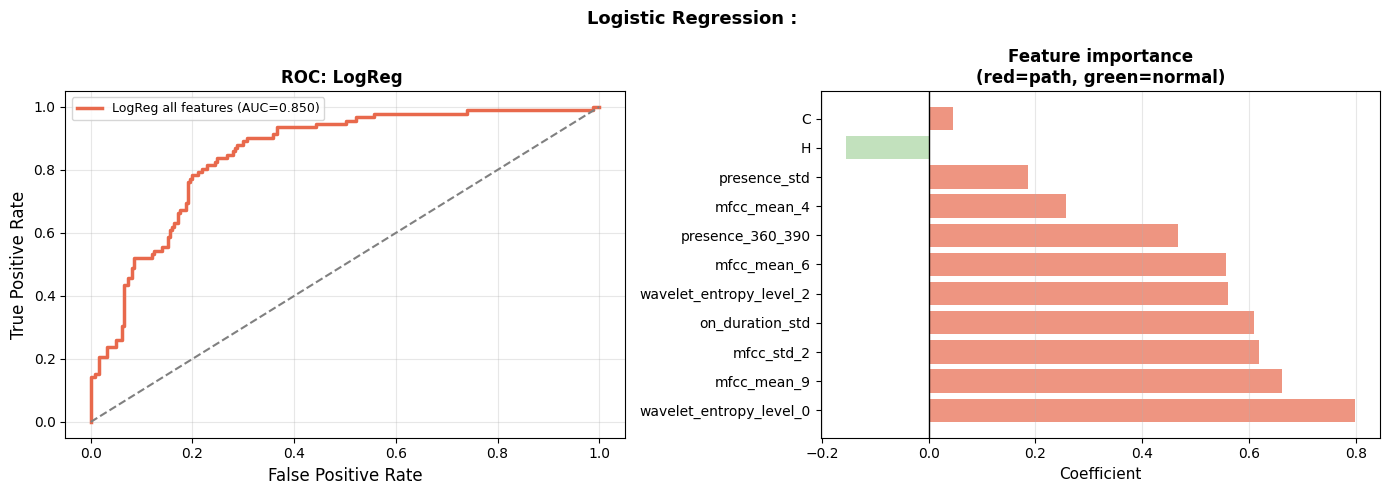


AUC all data: 0.850
CV AUC: 0.808 ± 0.052


In [47]:

lr.fit(X_scaled, y)
scores_lr = lr.predict_proba(X_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y, scores_lr)
roc_auc = auc(fpr, tpr)

# Coefficients
coef_df = pd.DataFrame({
    "feature":  feature_cols,
    "coef":     lr.coef_[0],
    "abs_coef": np.abs(lr.coef_[0])
}).sort_values("abs_coef", ascending=False)

print("Features importance:")
print(coef_df.to_string(index=False))

# График
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, linewidth=2.5, color="#E8694C",
        label=f"LogReg all features (AUC={roc_auc:.3f})")


fpr2, tpr2, _ = roc_curve(
    y,
    df_master["presence_360_390"].values
)

ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC: LogReg ",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)


ax = axes[1]
colors = ["#E8694C" if c > 0 else "#A8D5A2"
          for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"],
        color=colors, alpha=0.7)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Coefficient", fontsize=11)
ax.set_title("Feature importance\n(red=path, green=normal)",
             fontweight="bold")
ax.grid(alpha=0.3, axis="x")

plt.suptitle("Logistic Regression : ",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("LogReg_all_features.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nAUC all data: {roc_auc:.3f}")
print(f"CV AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

#Hidden Markov Model as feature extractor

In [48]:
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

all_seqs = []
all_labels = []
all_fnames = []

for p in sorted(FOLDER.glob("*.wav")):
    if p.name not in label_map_merged:
        continue
    lab = label_map_merged[p.name]
    y, sr = sf.read(p)
    y = np.asarray(y).reshape(-1).astype(float)
    y = y - y.mean()
    f, t, Sxx_db = compute_spectrogram(y, sr, nperseg=512, noverlap=384)
    mask = (f >= 260) & (f <= 290)
    seq = Sxx_db[mask, :].mean(axis=0).reshape(-1, 1)
    if len(seq) < 10:
        continue
    all_seqs.append(seq)
    all_labels.append(lab)
    all_fnames.append(p.name)


# Training a single general model on all data
X_all = np.concatenate(all_seqs)
lens_all = [len(s) for s in all_seqs]

model_joint = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=200, tol=1e-4,
    random_state=42
)
model_joint.fit(X_all, lens_all)

print("\nHidden states:")
for i in range(2):
    print(f"  S{i}: mean={model_joint.means_[i][0]:.3f}")
print("\nTransition matrix:")
print(model_joint.transmat_.round(3))


Hidden states:
  S0: mean=-48.283
  S1: mean=-68.070

Transition matrix:
[[0.988 0.012]
 [0.048 0.952]]


In [49]:
# For each file, calculate the percentage of time spent in each state
rows_joint = []
for seq, lab, fname in zip(all_seqs, all_labels, all_fnames):
    # Predicting a sequence of states
    states = model_joint.predict(seq)

    # Time spent in states 0 and 1
    frac_s0 = (states == 0).mean()
    frac_s1 = (states == 1).mean()

    # Number of transitions between states
    n_transitions = (np.diff(states) != 0).sum()
    transition_rate = n_transitions / len(states)

    #Average length of stay in each state
    runs_s1 = []
    count = 0
    for s in states:
        if s == 1:
            count += 1
        elif count > 0:
            runs_s1.append(count)
            count = 0
    mean_run_s1 = np.mean(runs_s1) if runs_s1 else 0

    rows_joint.append({
        "filename":        fname,
        "label":           lab,
        "frac_s0":         frac_s0,
        "frac_s1":         frac_s1,
        "transition_rate": transition_rate,
        "mean_run_s1":     mean_run_s1,
    })

df_joint = pd.DataFrame(rows_joint)

print("Stats:")
print(df_joint.groupby("label")[["frac_s1","transition_rate","mean_run_s1"]].describe().round(3))

Stats:
       frac_s1                                                transition_rate  \
         count   mean    std  min    25%    50%    75%    max           count   
label                                                                           
normal   259.0  0.163  0.298  0.0  0.000  0.000  0.171  1.000           259.0   
path      92.0  0.309  0.300  0.0  0.049  0.213  0.447  0.957            92.0   

               ...               mean_run_s1                                  \
         mean  ...    75%    max       count    mean     std  min  25%   50%   
label          ...                                                             
normal  0.010  ...  0.005  0.112       259.0  11.063  36.543  0.0  0.0   0.0   
path    0.024  ...  0.044  0.082        92.0  24.963  30.921  0.0  6.0  17.0   

                       
           75%    max  
label                  
normal   8.317  325.0  
path    32.500  144.5  

[2 rows x 24 columns]



AUC HMM features:
  frac_s1             : AUC=0.702, p=0.0000
  transition_rate     : AUC=0.741, p=0.0000
  mean_run_s1         : AUC=0.755, p=0.0000


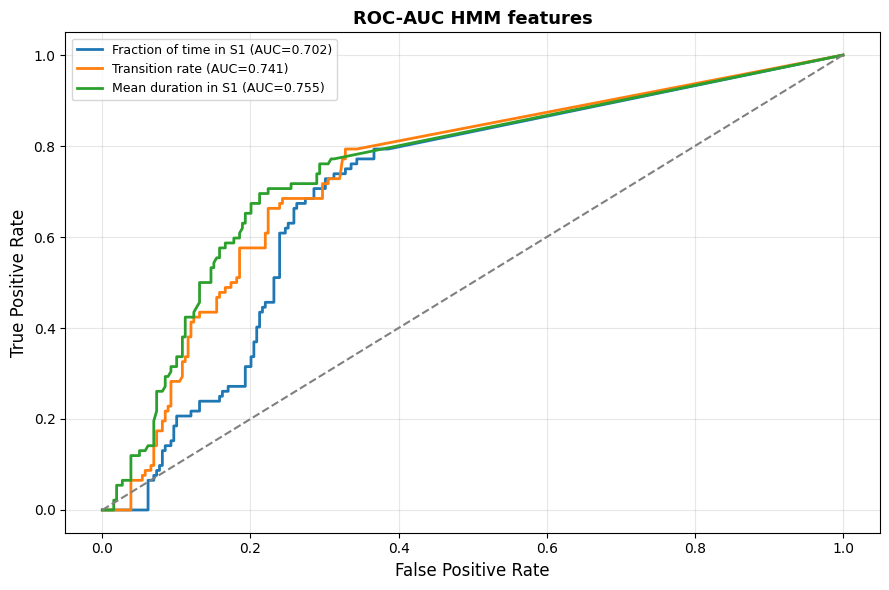

In [50]:

print("\nAUC HMM features:")


y_true = (df_joint["label"]=="path").astype(int).values

plt.figure(figsize=(9, 6))

for col, name in [
    ("frac_s1", "Fraction of time in S1"),
    ("transition_rate", "Transition rate"),
    ("mean_run_s1", "Mean duration in S1"),
    ]:
    scores = df_joint[col].values
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    if roc_auc < 0.5:
        fpr, tpr, _ = roc_curve(y_true, -scores)
        roc_auc = auc(fpr, tpr)

    _, pval = mannwhitneyu(
        df_joint[df_joint["label"]=="normal"][col],
        df_joint[df_joint["label"]=="path"][col],
        alternative="two-sided"
    )
    print(f"  {col:20s}: AUC={roc_auc:.3f}, p={pval:.4f}")
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC-AUC HMM features",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_HMM_joint.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
df_master4 = df_master.merge(
    df_joint[["filename", "mean_run_s1"]],
    on="filename",
    how="inner"
).dropna()

print(df_master4["label"].value_counts())

feature_cols5 = [
    "presence_360_390",
    "on_duration_std",
    "mfcc_mean_9",
    "mean_run_s1",
    "mfcc_mean_4",
    "mfcc_mean_6",
    "mfcc_std_2",
    "presence_std",
    "wavelet_entropy_level_0",
    "wavelet_entropy_level_2",
]

label
normal    257
path       92
Name: count, dtype: int64


#Lyapunov Exponent

In [ ]:
signal_lengths = [3000, 6000, 9000, 15000]

lyap_length_results = []

for sig_len in signal_lengths:

    df_tmp = compute_wavelet_lyapunov_for_folder(
        folder=FOLDER,
        label_map=label_map_merged,
        wavelet="db4",
        level=4,
        signal_len=sig_len,
        m=5,
        tau=1,
        max_iter=20
    )

    lyap_cols = [c for c in df_tmp.columns if c.startswith("lyap_")]

    df_res = evaluate_binary_features(
        df=df_tmp,
        feature_cols=lyap_cols,
        label_col="label",
        positive_label="path"
    )

    df_res["signal_len"] = sig_len
    df_res["duration_sec"] = sig_len / 3000

    lyap_length_results.append(df_res)

df_lyap_len = pd.concat(lyap_length_results, ignore_index=True)

display(
    df_lyap_len.sort_values(["feature", "signal_len"])
)

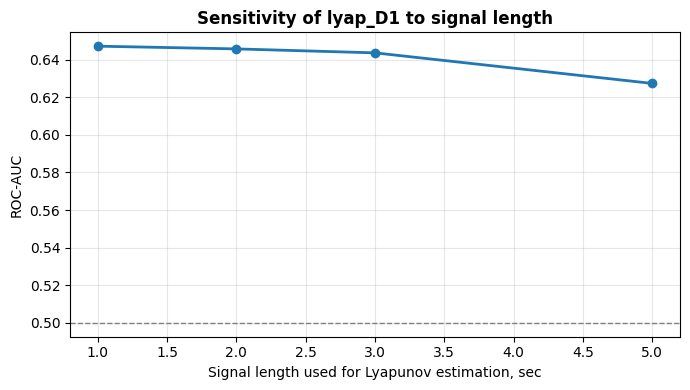

In [ ]:
plt.figure(figsize=(7, 4))

sub = df_lyap_len[df_lyap_len["feature"] == "lyap_D1"].sort_values("duration_sec")

plt.plot(sub["duration_sec"], sub["auc"], marker="o", linewidth=2)
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1)

plt.xlabel("Signal length used for Lyapunov estimation, sec")
plt.ylabel("ROC-AUC")
plt.title("Sensitivity of lyap_D1 to signal length", fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Files: 345
label
normal    256
path       89
Name: count, dtype: int64


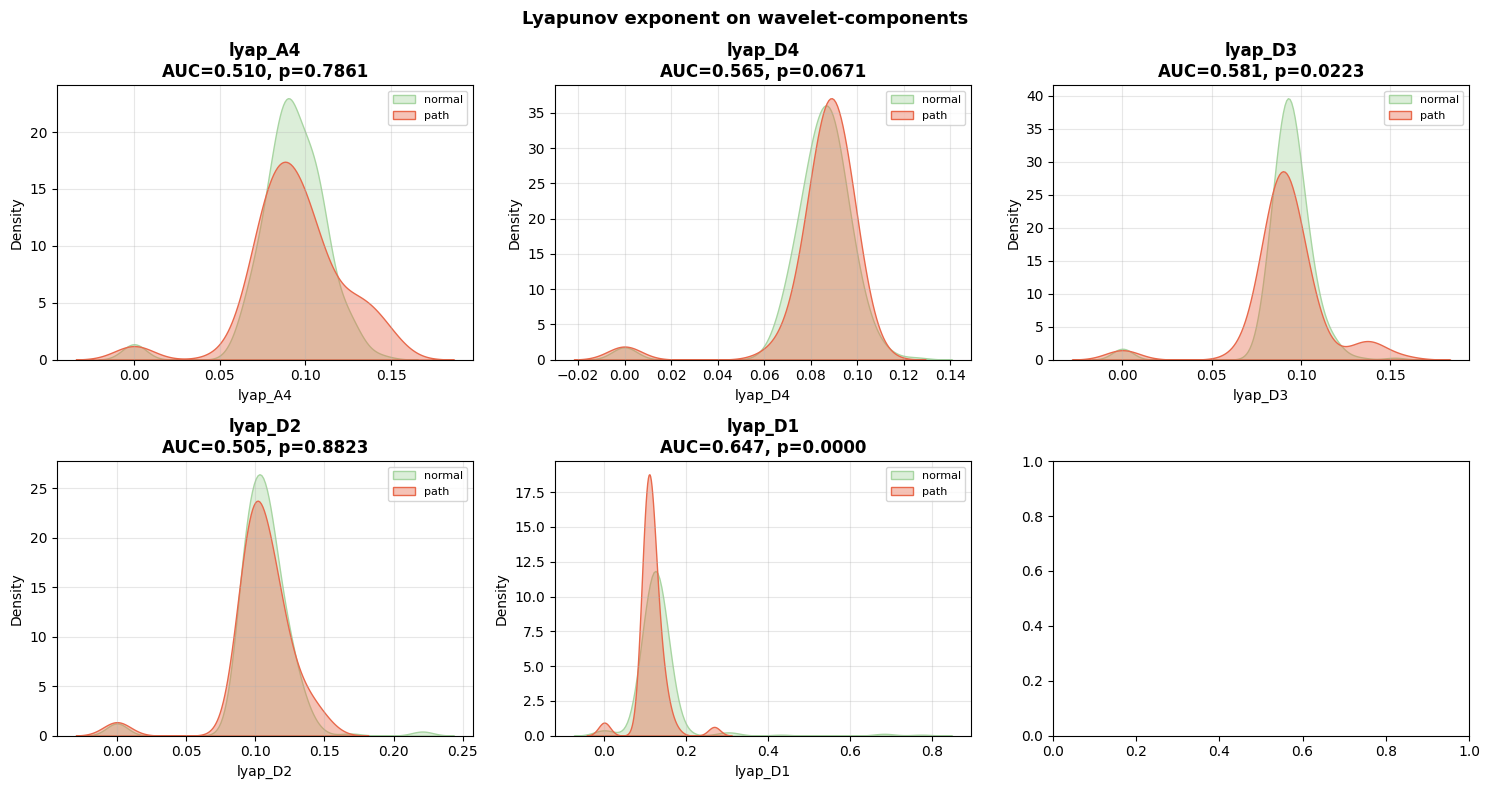

In [53]:

df_wlyap = compute_wavelet_lyapunov_for_folder(
    folder=FOLDER,
    label_map=label_map_merged,
    wavelet="db4",
    level=4,
    signal_len=3000,
    m=5,
    tau=1,
    max_iter=20
)

print(f"Files: {len(df_wlyap)}")
print(df_wlyap["label"].value_counts())
lyap_cols = [c for c in df_wlyap.columns if c.startswith("lyap_")]

df_wlyap_results = evaluate_binary_features(
    df=df_wlyap,
    feature_cols=lyap_cols,
    label_col="label",
    positive_label="path"
)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, lyap_cols):
    for lab, color in [("normal", "#A8D5A2"), ("path", "#E8694C")]:
        vals = df_wlyap[df_wlyap["label"] == lab][col].dropna()
        sns.kdeplot(
            vals,
            ax=ax,
            color=color,
            fill=True,
            alpha=0.4,
            label=lab
        )

    auc_val = df_wlyap_results[df_wlyap_results["feature"] == col]["auc"].values[0]
    p_val = df_wlyap_results[df_wlyap_results["feature"] == col]["pval"].values[0]

    ax.set_title(f"{col}\nAUC={auc_val:.3f}, p={p_val:.4f}", fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Lyapunov exponent on wavelet-components", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("wavelet_lyapunov_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

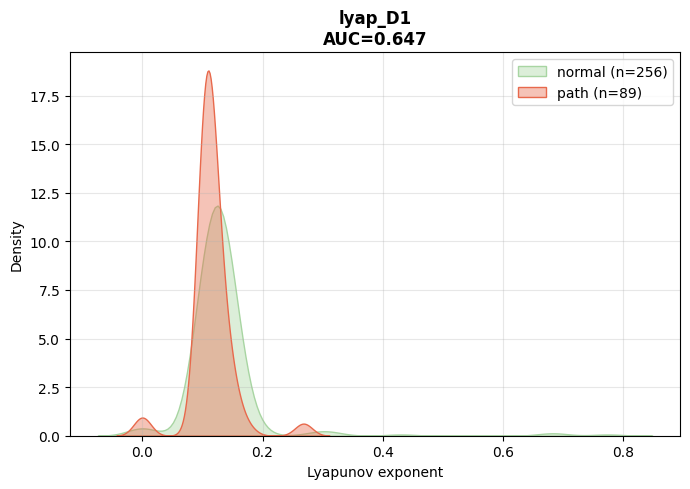

In [54]:
target_col = "lyap_D1"

auc_val = df_wlyap_results.loc[
    df_wlyap_results["feature"] == target_col, "auc"
].values[0]

plt.figure(figsize=(7, 5))

for lab, color in [("normal", "#A8D5A2"), ("path", "#E8694C")]:
    vals = df_wlyap[df_wlyap["label"] == lab][target_col].dropna()
    sns.kdeplot(
        vals,
        color=color,
        fill=True,
        alpha=0.4,
        label=f"{lab} (n={len(vals)})"
    )

plt.title(
    f"{target_col}\nAUC={auc_val:.3f}",
    fontweight="bold"
)
plt.xlabel("Lyapunov exponent")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("lyap_D1_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
df_master_lyap = df_master4.merge(
    df_wlyap[["filename", "lyap_D1"]],
    on="filename",
    how="inner"
).dropna()

feature_cols_lyap = feature_cols5 + ["lyap_D1"]

X_lyap = df_master_lyap[feature_cols_lyap].values
y_lyap = (df_master_lyap["label"] == "path").astype(int).values


In [56]:


X_clean = X_lyap
y_clean = y_lyap

n_iter = 100
results_mc_hmm_lyap = []

ss = StratifiedShuffleSplit(
    n_splits=n_iter,
    test_size=0.2,
    random_state=42
)

for iteration, (train_idx, test_idx) in enumerate(ss.split(X_clean, y_clean)):
    X_tr, X_te = X_clean[train_idx], X_clean[test_idx]
    y_tr, y_te = y_clean[train_idx], y_clean[test_idx]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    lr_mc = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=0.15
    )

    lr_mc.fit(X_tr_sc, y_tr)

    proba_te = lr_mc.predict_proba(X_te_sc)[:, 1]
    pred_te = lr_mc.predict(X_te_sc)

    fpr_te, tpr_te, _ = roc_curve(y_te, proba_te)
    test_auc = auc(fpr_te, tpr_te)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te).ravel()

    results_mc_hmm_lyap.append({
        "iteration": iteration,
        "test_auc": test_auc,
        "recall": tp / (tp + fn + 1e-10),
        "precision": tp / (tp + fp + 1e-10),
        "f1": 2 * tp / (2 * tp + fp + fn + 1e-10),
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

    if (iteration + 1) % 10 == 0:
        print(f"Iteration {iteration + 1}/{n_iter}...")

df_mc_hmm_lyap = pd.DataFrame(results_mc_hmm_lyap)

print(f"\nMonte Carlo LogReg + HMM + lyap_D1 ({n_iter} iterations)\n")
print(f"Test AUC:    {df_mc_hmm_lyap['test_auc'].mean():.3f} ± {df_mc_hmm_lyap['test_auc'].std():.3f}")
print(f"Recall: {df_mc_hmm_lyap['recall'].mean():.3f} ± {df_mc_hmm_lyap['recall'].std():.3f}")
print(f"Precision:   {df_mc_hmm_lyap['precision'].mean():.3f} ± {df_mc_hmm_lyap['precision'].std():.3f}")
print(f"F1:          {df_mc_hmm_lyap['f1'].mean():.3f} ± {df_mc_hmm_lyap['f1'].std():.3f}")
print(f"Accuracy:    {df_mc_hmm_lyap['accuracy'].mean():.3f} ± {df_mc_hmm_lyap['accuracy'].std():.3f}")
print(f"Features: {feature_cols_lyap}")

Iteration 10/100...
Iteration 20/100...
Iteration 30/100...
Iteration 40/100...
Iteration 50/100...
Iteration 60/100...
Iteration 70/100...
Iteration 80/100...
Iteration 90/100...
Iteration 100/100...

Monte Carlo LogReg + HMM + lyap_D1 (100 iterations)

Test AUC:    0.834 ± 0.053
Recall: 0.337 ± 0.125
Precision:   0.654 ± 0.148
F1:          0.434 ± 0.128
Accuracy:    0.779 ± 0.040
Features: ['presence_360_390', 'on_duration_std', 'mfcc_mean_9', 'mean_run_s1', 'mfcc_mean_4', 'mfcc_mean_6', 'mfcc_std_2', 'presence_std', 'wavelet_entropy_level_0', 'wavelet_entropy_level_2', 'lyap_D1']


In [57]:
scaler_lyap = StandardScaler()
X_lyap_scaled = scaler_lyap.fit_transform(X_lyap)

lr_coef_lyap = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=0.15
)

lr_coef_lyap.fit(X_lyap_scaled, y_lyap)

coef_lyap = pd.DataFrame({
    "feature": feature_cols_lyap,
    "coef": lr_coef_lyap.coef_[0],
    "abs_coef": np.abs(lr_coef_lyap.coef_[0])
}).sort_values("abs_coef", ascending=False)

print("Importance of features in log regression:")
print(coef_lyap.to_string(index=False))

Importance of features in log regression:
                feature      coef  abs_coef
wavelet_entropy_level_0  0.705176  0.705176
             mfcc_std_2  0.578896  0.578896
                lyap_D1 -0.523573  0.523573
            mfcc_mean_9  0.423985  0.423985
            mfcc_mean_6  0.394246  0.394246
       presence_360_390  0.385171  0.385171
wavelet_entropy_level_2  0.376923  0.376923
        on_duration_std  0.260260  0.260260
            mfcc_mean_4  0.208858  0.208858
            mean_run_s1  0.076337  0.076337
           presence_std -0.054789  0.054789


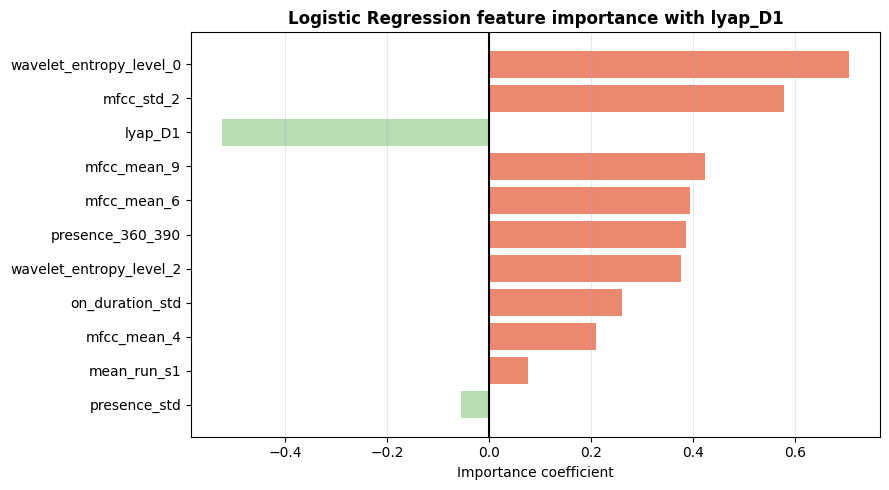

In [58]:
plt.figure(figsize=(9, 5))

colors = [
    "#E8694C" if c > 0 else "#A8D5A2"
    for c in coef_lyap["coef"]
]

plt.barh(
    coef_lyap["feature"],
    coef_lyap["coef"],
    color=colors,
    alpha=0.8
)

plt.axvline(0, color="black")
plt.xlabel("Importance coefficient")
plt.title("Logistic Regression feature importance with lyap_D1", fontweight="bold" )
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("logreg_feature_importance_lyap_D1.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
# LogReg + lyap_D1 with HMM and without H,C

df_master_lyap_no_hmm = df_master.merge(
    df_wlyap[["filename", "lyap_D1"]],
    on="filename",
    how="inner"
).dropna()

print(f"Number of rows: {len(df_master_lyap_no_hmm)}")
print(df_master_lyap_no_hmm["label"].value_counts())

feature_cols_lyap_no_hmm = [
    "presence_360_390",
    "on_duration_std",
    "mfcc_mean_9",
    "mfcc_mean_4",
    "mfcc_mean_6",
    "mfcc_std_2",
    "presence_std",
    "wavelet_entropy_level_0",
    "wavelet_entropy_level_2",
    "lyap_D1",
]

X_clean = df_master_lyap_no_hmm[feature_cols_lyap_no_hmm].values
y_clean = (df_master_lyap_no_hmm["label"] == "path").astype(int).values

n_iter = 100
results_mc_lyap_no_hmm = []

ss = StratifiedShuffleSplit(
    n_splits=n_iter,
    test_size=0.2,
    random_state=42
)

for iteration, (train_idx, test_idx) in enumerate(ss.split(X_clean, y_clean)):
    X_tr, X_te = X_clean[train_idx], X_clean[test_idx]
    y_tr, y_te = y_clean[train_idx], y_clean[test_idx]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    lr_mc = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=0.15
    )

    lr_mc.fit(X_tr_sc, y_tr)

    proba_te = lr_mc.predict_proba(X_te_sc)[:, 1]
    pred_te = lr_mc.predict(X_te_sc)

    fpr_te, tpr_te, _ = roc_curve(y_te, proba_te)
    test_auc = auc(fpr_te, tpr_te)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te).ravel()

    results_mc_lyap_no_hmm.append({
        "iteration": iteration,
        "test_auc": test_auc,
        "recall": tp / (tp + fn + 1e-10),
        "precision": tp / (tp + fp + 1e-10),
        "f1": 2 * tp / (2 * tp + fp + fn + 1e-10),
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

df_mc_lyap_no_hmm = pd.DataFrame(results_mc_lyap_no_hmm)

print(f"\nMonte Carlo LogReg + lyap_D1 without HMM and without H,C ({n_iter} iterations)\n")
print(f"Test AUC:    {df_mc_lyap_no_hmm['test_auc'].mean():.3f} ± {df_mc_lyap_no_hmm['test_auc'].std():.3f}")
print(f"Recall: {df_mc_lyap_no_hmm['recall'].mean():.3f} ± {df_mc_lyap_no_hmm['recall'].std():.3f}")
print(f"Precision:   {df_mc_lyap_no_hmm['precision'].mean():.3f} ± {df_mc_lyap_no_hmm['precision'].std():.3f}")
print(f"F1:          {df_mc_lyap_no_hmm['f1'].mean():.3f} ± {df_mc_lyap_no_hmm['f1'].std():.3f}")
print(f"Accuracy:    {df_mc_lyap_no_hmm['accuracy'].mean():.3f} ± {df_mc_lyap_no_hmm['accuracy'].std():.3f}")

Number of rows: 343
label
normal    254
path       89
Name: count, dtype: int64

Monte Carlo LogReg + lyap_D1 without HMM and without H,C (100 iterations)

Test AUC:    0.832 ± 0.054
Recall: 0.337 ± 0.127
Precision:   0.684 ± 0.165
F1:          0.440 ± 0.135
Accuracy:    0.785 ± 0.042


In [60]:
# LogReg + lyap_D1 without HMM

df_master_lyap_no_hmm = df_master.merge(
    df_wlyap[["filename", "lyap_D1"]],
    on="filename",
    how="inner"
).dropna()

print(f"Строк: {len(df_master_lyap_no_hmm)}")
print(df_master_lyap_no_hmm["label"].value_counts())

# features without HMM
feature_cols_no_hmm = [
    "presence_360_390",
    "H", "C",
    "mfcc_mean_4",
    "mfcc_mean_6",
    "mfcc_std_2",
    "mfcc_mean_9",
    "on_duration_std",
    "presence_std",
    "wavelet_entropy_level_0",
    "wavelet_entropy_level_2",
]

# add lyap_D1
feature_cols_lyap_no_hmm = feature_cols_no_hmm + ["lyap_D1"]

X_clean = df_master_lyap_no_hmm[feature_cols_lyap_no_hmm].values
y_clean = (df_master_lyap_no_hmm["label"] == "path").astype(int).values

n_iter = 100
results_mc_lyap_no_hmm = []

ss = StratifiedShuffleSplit(
    n_splits=n_iter,
    test_size=0.2,
    random_state=42
)

for iteration, (train_idx, test_idx) in enumerate(ss.split(X_clean, y_clean)):
    X_tr, X_te = X_clean[train_idx], X_clean[test_idx]
    y_tr, y_te = y_clean[train_idx], y_clean[test_idx]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    lr_mc = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=0.15
    )

    lr_mc.fit(X_tr_sc, y_tr)

    proba_te = lr_mc.predict_proba(X_te_sc)[:, 1]
    pred_te = lr_mc.predict(X_te_sc)

    fpr_te, tpr_te, _ = roc_curve(y_te, proba_te)
    test_auc = auc(fpr_te, tpr_te)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te).ravel()

    results_mc_lyap_no_hmm.append({
        "iteration": iteration,
        "test_auc": test_auc,
        "recall": tp / (tp + fn + 1e-10),
        "precision": tp / (tp + fp + 1e-10),
        "f1": 2 * tp / (2 * tp + fp + fn + 1e-10),
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

    if (iteration + 1) % 10 == 0:
        print(f"Iteration {iteration + 1}/{n_iter}...")

df_mc_lyap_no_hmm = pd.DataFrame(results_mc_lyap_no_hmm)

print(f"\nMonte Carlo LogReg + lyap_D1 without HMM ({n_iter} iterations)\n")

print(f"Test AUC:    {df_mc_lyap_no_hmm['test_auc'].mean():.3f} ± {df_mc_lyap_no_hmm['test_auc'].std():.3f}")
print(f"Recall: {df_mc_lyap_no_hmm['recall'].mean():.3f} ± {df_mc_lyap_no_hmm['recall'].std():.3f}")
print(f"Precision:   {df_mc_lyap_no_hmm['precision'].mean():.3f} ± {df_mc_lyap_no_hmm['precision'].std():.3f}")
print(f"F1:          {df_mc_lyap_no_hmm['f1'].mean():.3f} ± {df_mc_lyap_no_hmm['f1'].std():.3f}")
print(f"Accuracy:    {df_mc_lyap_no_hmm['accuracy'].mean():.3f} ± {df_mc_lyap_no_hmm['accuracy'].std():.3f}")

Строк: 343
label
normal    254
path       89
Name: count, dtype: int64
Iteration 10/100...
Iteration 20/100...
Iteration 30/100...
Iteration 40/100...
Iteration 50/100...
Iteration 60/100...
Iteration 70/100...
Iteration 80/100...
Iteration 90/100...
Iteration 100/100...

Monte Carlo LogReg + lyap_D1 without HMM (100 iterations)

Test AUC:    0.838 ± 0.053
Recall: 0.347 ± 0.122
Precision:   0.645 ± 0.148
F1:          0.441 ± 0.125
Accuracy:    0.777 ± 0.042


In [61]:
# feature importance LogReg + lyap_D1 without HMM

scaler_lyap_no_hmm = StandardScaler()
X_scaled = scaler_lyap_no_hmm.fit_transform(X_clean)

lr_coef_lyap_no_hmm = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=0.15
)

lr_coef_lyap_no_hmm.fit(X_scaled, y_clean)

coef_lyap_no_hmm = pd.DataFrame({
    "feature": feature_cols_lyap_no_hmm,
    "coef": lr_coef_lyap_no_hmm.coef_[0],
    "abs_coef": np.abs(lr_coef_lyap_no_hmm.coef_[0])
}).sort_values("abs_coef", ascending=False)

display(coef_lyap_no_hmm)

,feature,coef,abs_coef
9,wavelet_entropy_level_0,0.690112,0.690112
11,lyap_D1,-0.569915,0.569915
6,mfcc_mean_9,0.521578,0.521578
5,mfcc_std_2,0.509806,0.509806
4,mfcc_mean_6,0.406025,0.406025
0,presence_360_390,0.403908,0.403908
10,wavelet_entropy_level_2,0.347369,0.347369
7,on_duration_std,0.278896,0.278896
3,mfcc_mean_4,0.266125,0.266125
1,H,-0.126824,0.126824


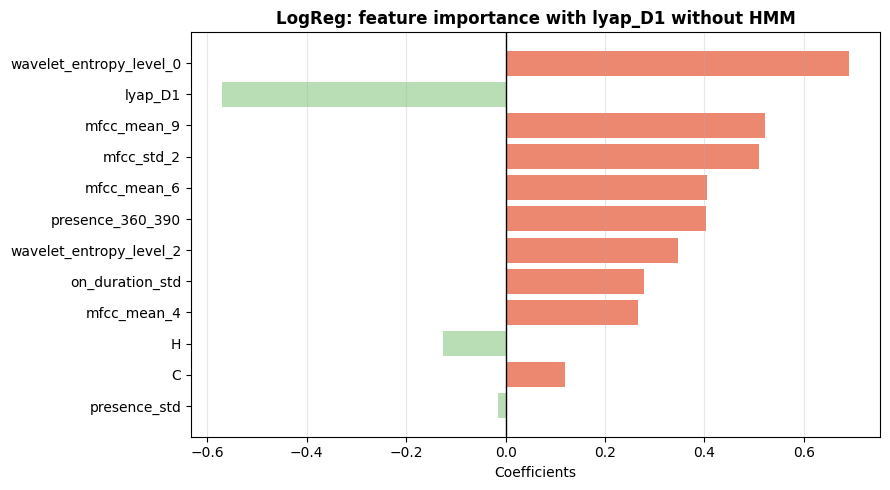

In [62]:
plt.figure(figsize=(9, 5))

colors = [
    "#E8694C" if c > 0 else "#A8D5A2"
    for c in coef_lyap_no_hmm["coef"]
]

plt.barh(
    coef_lyap_no_hmm["feature"],
    coef_lyap_no_hmm["coef"],
    color=colors,
    alpha=0.8
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficients")
plt.title("LogReg: feature importance with lyap_D1 without HMM", fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("logreg_feature_importance_lyap_D1_noHMM.png", dpi=300, bbox_inches="tight")
plt.show()

# Logistic Regression

##Monte-Carlo method

---



In [63]:
df_master4 = df_master.merge(
    df_joint[["filename", "mean_run_s1"]],
    on="filename",
    how="inner"
).dropna()

print(f"rows: {len(df_master4)}")
print(df_master4["label"].value_counts())

rows: 349
label
normal    257
path       92
Name: count, dtype: int64


In [64]:

feature_cols5 = [
    "presence_360_390",
    "H", "C",
    "on_duration_std",
    "mfcc_mean_9",
    "mean_run_s1",
    "mfcc_mean_4",
    "mfcc_mean_6",
    "mfcc_std_2",
    "presence_std",
    "wavelet_entropy_level_0",
    "wavelet_entropy_level_2",
]

X5 = df_master4[feature_cols5].values
y5 = (df_master4["label"] == "path").astype(int).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr5 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42, C=0.15)
)

auc_scores5 = cross_val_score(lr5, X5, y5, cv=cv, scoring="roc_auc")

print(f"CV AUC + HMM feature: {auc_scores5.mean():.3f} ± {auc_scores5.std():.3f}")
print(f"CV AUC without HMM:       {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

CV AUC + HMM feature: 0.818 ± 0.062
CV AUC without HMM:       0.808 ± 0.052


In [65]:
X_clean = df_master4[feature_cols5].values
y_clean = (df_master4["label"] == "path").astype(int).values

n_iter = 100
results_mc = []

ss = StratifiedShuffleSplit(
    n_splits=n_iter,
    test_size=0.2,
    random_state=42
)

for iteration, (train_idx, test_idx) in enumerate(ss.split(X_clean, y_clean)):
    X_tr, X_te = X_clean[train_idx], X_clean[test_idx]
    y_tr, y_te = y_clean[train_idx], y_clean[test_idx]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    lr_mc = LogisticRegression(max_iter=1000, random_state=42, C=0.15)
    lr_mc.fit(X_tr_sc, y_tr)

    proba_te = lr_mc.predict_proba(X_te_sc)[:, 1]
    pred_te = lr_mc.predict(X_te_sc)

    fpr_te, tpr_te, _ = roc_curve(y_te, proba_te)
    test_auc = auc(fpr_te, tpr_te)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te).ravel()

    results_mc.append({
        "iteration": iteration,
        "test_auc": test_auc,
        "recall": tp / (tp + fn + 1e-10),
        "precision": tp / (tp + fp + 1e-10),
        "f1": 2 * tp / (2 * tp + fp + fn + 1e-10),
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

df_mc = pd.DataFrame(results_mc)

print(f"Monte Carlo LogReg + HMM ({n_iter} iterations)\n")
print(f"Test AUC:    {df_mc['test_auc'].mean():.3f} ± {df_mc['test_auc'].std():.3f}")
print(f"Recall:      {df_mc['recall'].mean():.3f} ± {df_mc['recall'].std():.3f}")
print(f"Precision:   {df_mc['precision'].mean():.3f} ± {df_mc['precision'].std():.3f}")
print(f"F1:          {df_mc['f1'].mean():.3f} ± {df_mc['f1'].std():.3f}")
print(f"Accuracy:    {df_mc['accuracy'].mean():.3f} ± {df_mc['accuracy'].std():.3f}")
print(f"Features: {feature_cols5}")

Monte Carlo LogReg + HMM (100 iterations)

Test AUC:    0.828 ± 0.052
Recall:      0.308 ± 0.105
Precision:   0.625 ± 0.165
F1:          0.402 ± 0.110
Accuracy:    0.771 ± 0.035
Features: ['presence_360_390', 'H', 'C', 'on_duration_std', 'mfcc_mean_9', 'mean_run_s1', 'mfcc_mean_4', 'mfcc_mean_6', 'mfcc_std_2', 'presence_std', 'wavelet_entropy_level_0', 'wavelet_entropy_level_2']


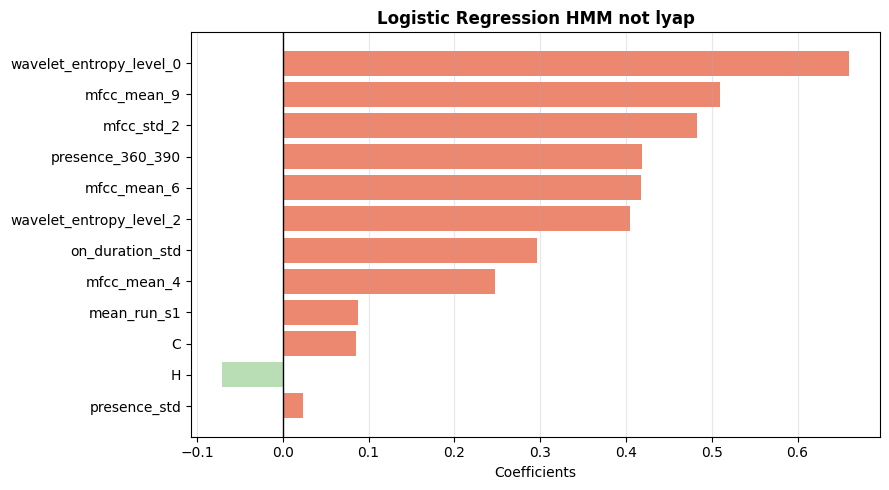

In [66]:
scaler5 = StandardScaler()
X5_scaled = scaler5.fit_transform(X5)

lr_coef = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=0.15
)

lr_coef.fit(X5_scaled, y5)

coef5 = pd.DataFrame({
    "feature": feature_cols5,
    "coef": lr_coef.coef_[0],
    "abs_coef": np.abs(lr_coef.coef_[0])
}).sort_values("abs_coef", ascending=False)

plt.figure(figsize=(9, 5))

colors = [
    "#E8694C" if c > 0 else "#A8D5A2"
    for c in coef5["coef"]
]

plt.barh(
    coef5["feature"],
    coef5["coef"],
    color=colors,
    alpha=0.8
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Coefficients")
plt.title("Logistic Regression HMM not lyap", fontweight="bold")

plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("logreg_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

#Gradient Boosting

In [67]:
X5 = df_master4[feature_cols5].values
y5 = (df_master4["label"] == "path").astype(int).values

print("Size of X:", X5.shape)
print("Path:", y5.sum(), "Normal:", (1 - y5).sum())

Size of X: (349, 12)
Path: 92 Normal: 257


In [68]:
df_master4.columns

Index(['filename', 'label', 'presence_360_390', 'H', 'C', 'mfcc_mean_4',
       'mfcc_mean_6', 'mfcc_std_2', 'mfcc_mean_9', 'on_duration_std',
       'presence_std', 'wavelet_entropy_level_0', 'wavelet_entropy_level_2',
       'mean_run_s1'],
      dtype='object')

In [71]:
n_iter = 100
results_mc_hgb = []

ss = StratifiedShuffleSplit(
    n_splits=n_iter,
    test_size=0.2,
    random_state=42
)

for iteration, (train_idx, test_idx) in enumerate(ss.split(X5, y5)):
    X_tr, X_te = X5[train_idx], X5[test_idx]
    y_tr, y_te = y5[train_idx], y5[test_idx]

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_tr
    )

    hgb = HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    )

    hgb.fit(
        X_tr,
        y_tr,
        sample_weight=sample_weights
    )

    proba_te = hgb.predict_proba(X_te)[:, 1]
    pred_te = hgb.predict(X_te)

    fpr_te, tpr_te, _ = roc_curve(y_te, proba_te)
    test_auc = auc(fpr_te, tpr_te)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te).ravel()

    results_mc_hgb.append({
        "iteration": iteration,
        "test_auc": test_auc,
        "recall": tp / (tp + fn + 1e-10),
        "precision": tp / (tp + fp + 1e-10),
        "f1": 2 * tp / (2 * tp + fp + fn + 1e-10),
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
    })

    if (iteration + 1) % 10 == 0:
        print(f"iteration {iteration + 1}/{n_iter}...")

df_mc_hgb = pd.DataFrame(results_mc_hgb)


print("\nMonte Carlo Boosting HMM + H, C")
print(" ")

print(f"Test AUC:    {df_mc_hgb['test_auc'].mean():.3f} ± {df_mc_hgb['test_auc'].std():.3f}")
print(f"Recall:      {df_mc_hgb['recall'].mean():.3f} ± {df_mc_hgb['recall'].std():.3f}")
print(f"Precision:   {df_mc_hgb['precision'].mean():.3f} ± {df_mc_hgb['precision'].std():.3f}")
print(f"F1:          {df_mc_hgb['f1'].mean():.3f} ± {df_mc_hgb['f1'].std():.3f}")
print(f"Accuracy:    {df_mc_hgb['accuracy'].mean():.3f} ± {df_mc_hgb['accuracy'].std():.3f}")

iteration 10/100...
iteration 20/100...
iteration 30/100...
iteration 40/100...
iteration 50/100...
iteration 60/100...
iteration 70/100...
iteration 80/100...
iteration 90/100...
iteration 100/100...

Monte Carlo Boosting HMM + H, C
 
Test AUC:    0.865 ± 0.053
Recall:      0.714 ± 0.111
Precision:   0.665 ± 0.086
F1:          0.683 ± 0.080
Accuracy:    0.831 ± 0.044



PATH  P(path) = 0.996 


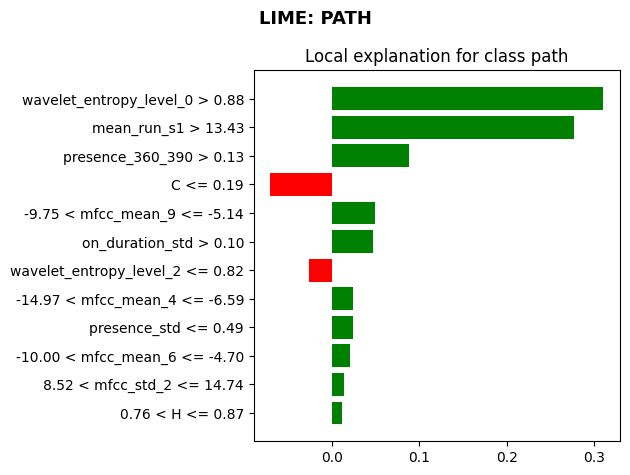


NORMAL  P(path) = 0.001 


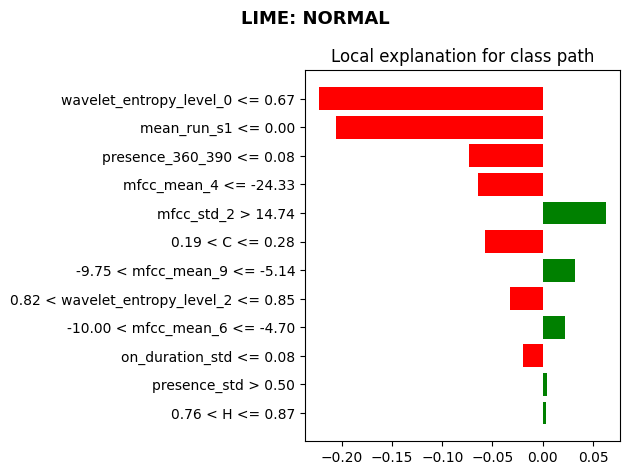

In [72]:
sample_weights_all = compute_sample_weight(
    class_weight="balanced",
    y=y5
)

hgb_lime = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    max_iter=200,
    random_state=42
)

hgb_lime.fit(
    X5,
    y5,
    sample_weight=sample_weights_all
)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X5,
    feature_names=feature_cols5,
    class_names=["normal", "path"],
    mode="classification",
    random_state=42
)

proba_all = hgb_lime.predict_proba(X5)[:, 1]
pred_all = hgb_lime.predict(X5)

path_candidates = np.where((y5 == 1) & (pred_all == 1))[0]
normal_candidates = np.where((y5 == 0) & (pred_all == 0))[0]

path_idx = path_candidates[np.argmax(proba_all[path_candidates])]
normal_idx = normal_candidates[np.argmin(proba_all[normal_candidates])]

for idx, title in [(path_idx, "PATH"), (normal_idx, "NORMAL")]:

    exp = explainer.explain_instance(
        data_row=X5[idx],
        predict_fn=hgb_lime.predict_proba,
        num_features=len(feature_cols5)
    )

    print(f"\n{title}  P(path) = {proba_all[idx]:.3f} ")

    fig = exp.as_pyplot_figure()

    fig.suptitle(
        f"LIME: {title}",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"lime_{title.lower()}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

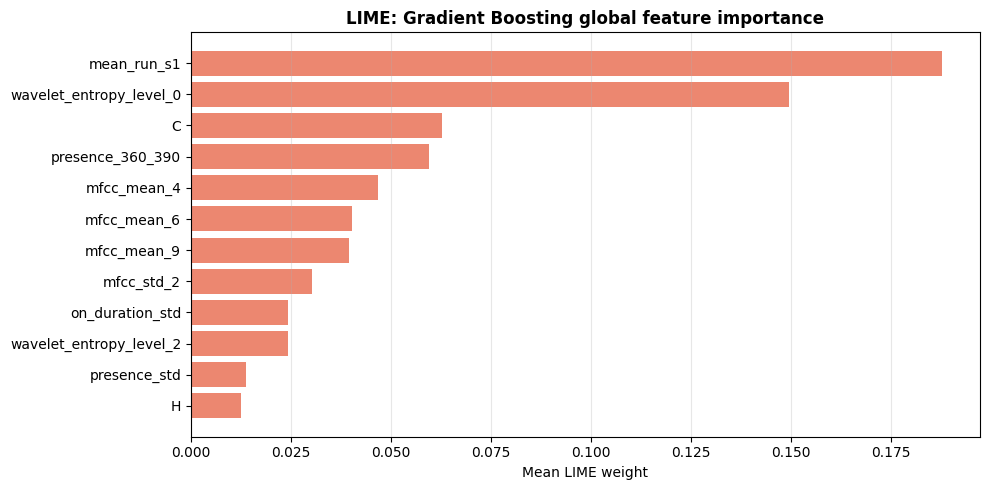

In [73]:
feature_weights = defaultdict(list)

for i in range(len(X5)):

    exp = explainer.explain_instance(
        data_row=X5[i],
        predict_fn=hgb_lime.predict_proba,
        num_features=len(feature_cols5)
    )

    for feat_idx, weight in exp.as_map()[1]:
        feature_weights[feature_cols5[feat_idx]].append(abs(weight))

mean_weights = {
    f: np.mean(w)
    for f, w in feature_weights.items()
}

mean_weights = dict(
    sorted(
        mean_weights.items(),
        key=lambda x: x[1],
        reverse=True
    )
)
plt.figure(figsize=(10, 5))

plt.barh(
    list(mean_weights.keys()),
    list(mean_weights.values()),
    color="#E8694C",
    alpha=0.8
)

plt.xlabel("Mean LIME weight")

plt.title(
    "LIME: Gradient Boosting global feature importance",
    fontweight="bold"
)

plt.gca().invert_yaxis()

plt.grid(alpha=0.3, axis="x")

plt.tight_layout()

plt.savefig(
    "lime_global.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

#Gradient Boosting + Lyapunov Exponent

In [76]:
# Final table with + lyap_D1
df_boost_lyap = df_master4.merge(
    df_wlyap[["filename", "lyap_D1"]],
    on="filename",
    how="inner"
).dropna()

print(f"Rows: {len(df_boost_lyap)}")
print(df_boost_lyap["label"].value_counts())

# Features: HMM + H,C + lyap_D1
feature_cols_boost_lyap = [
    "presence_360_390",
    "on_duration_std",
    "mfcc_mean_9",
    "mean_run_s1",
    "mfcc_mean_4",
    "mfcc_mean_6",
    "mfcc_std_2",
    "presence_std",
    "wavelet_entropy_level_0",
    "wavelet_entropy_level_2",
    "H",
    "C",
    "lyap_D1",
]

X_boost_lyap = df_boost_lyap[feature_cols_boost_lyap].values
y_boost_lyap = (df_boost_lyap["label"] == "path").astype(int).values

print("Path:", y_boost_lyap.sum(), "Normal:", (1 - y_boost_lyap).sum())

n_iter = 100
results_mc_hgb_lyap = []

ss = StratifiedShuffleSplit(
    n_splits=n_iter,
    test_size=0.2,
    random_state=42
)

for iteration, (train_idx, test_idx) in enumerate(ss.split(X_boost_lyap, y_boost_lyap)):
    X_tr, X_te = X_boost_lyap[train_idx], X_boost_lyap[test_idx]
    y_tr, y_te = y_boost_lyap[train_idx], y_boost_lyap[test_idx]

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_tr
    )

    hgb = HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    )

    hgb.fit(
        X_tr,
        y_tr,
        sample_weight=sample_weights
    )

    proba_te = hgb.predict_proba(X_te)[:, 1]
    pred_te = hgb.predict(X_te)

    fpr_te, tpr_te, _ = roc_curve(y_te, proba_te)
    test_auc = auc(fpr_te, tpr_te)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te).ravel()

    results_mc_hgb_lyap.append({
        "iteration": iteration,
        "test_auc": test_auc,
        "recall": tp / (tp + fn + 1e-10),
        "precision": tp / (tp + fp + 1e-10),
        "f1": 2 * tp / (2 * tp + fp + fn + 1e-10),
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

    if (iteration + 1) % 10 == 0:
        print(f"Iteration {iteration + 1}/{n_iter}...")

df_mc_hgb_lyap = pd.DataFrame(results_mc_hgb_lyap)

print("\nMonte Carlo Boosting HMM + H,C + lyap_D1\n")
print(f"Test AUC:    {df_mc_hgb_lyap['test_auc'].mean():.3f} ± {df_mc_hgb_lyap['test_auc'].std():.3f}")
print(f"Recall:      {df_mc_hgb_lyap['recall'].mean():.3f} ± {df_mc_hgb_lyap['recall'].std():.3f}")
print(f"Precision:   {df_mc_hgb_lyap['precision'].mean():.3f} ± {df_mc_hgb_lyap['precision'].std():.3f}")
print(f"F1:          {df_mc_hgb_lyap['f1'].mean():.3f} ± {df_mc_hgb_lyap['f1'].std():.3f}")
print(f"Accuracy:    {df_mc_hgb_lyap['accuracy'].mean():.3f} ± {df_mc_hgb_lyap['accuracy'].std():.3f}")

Rows: 343
label
normal    254
path       89
Name: count, dtype: int64
Path: 89 Normal: 254
Iteration 10/100...
Iteration 20/100...
Iteration 30/100...
Iteration 40/100...
Iteration 50/100...
Iteration 60/100...
Iteration 70/100...
Iteration 80/100...
Iteration 90/100...
Iteration 100/100...

Monte Carlo Boosting HMM + H,C + lyap_D1

Test AUC:    0.857 ± 0.050
Recall:      0.708 ± 0.102
Precision:   0.662 ± 0.085
F1:          0.679 ± 0.072
Accuracy:    0.826 ± 0.041


#Part where I tried to squeeze the juice out of a hidden Markov model as a classifier
Spoiler: it didn't work out

In [77]:
def extract_frame_features(p, sr=3000, n_mfcc=13,
                             bands=[(260,290),(360,390),(290,320)],
                             nperseg=512, noverlap=384):
    """
 For each file, returns a matrix (T, n_features)
 where T is the number of frames
 """
    y, sr = sf.read(p)
    y = np.asarray(y).reshape(-1).astype(float)
    y = y - y.mean()

    # Spectrogram for frequency bands
    f, t, Sxx_db = compute_spectrogram(y, sr, nperseg=nperseg, noverlap=noverlap)

    # Power of each band by frame -  shape (T, n_bands)
    band_features = []
    for band_lo, band_hi in bands:
        mask = (f >= band_lo) & (f <= band_hi)
        band_power = Sxx_db[mask, :].mean(axis=0)  # (T,)
        band_features.append(band_power)
    band_features = np.stack(band_features, axis=1)  # (T, n_bands)

    # MFCC by frames — shape (T, n_mfcc)
    # hop_length must match noverlap
    hop = nperseg - noverlap
    mfcc = librosa.feature.mfcc(
        y=y.astype(np.float32), sr=sr,
        n_mfcc=n_mfcc,
        hop_length=hop,
        n_fft=nperseg
    ).T

    # Cut to the same length
    min_len = min(band_features.shape[0], mfcc.shape[0])
    band_features = band_features[:min_len]
    mfcc = mfcc[:min_len]

    features = np.concatenate([band_features, mfcc], axis=1)
    return features

all_seqs_multi = []
all_labels_multi = []
all_fnames_multi = []

for p in sorted(FOLDER.glob("*.wav")):
    if p.name not in label_map_merged:
        continue
    lab = label_map_merged[p.name]

    seq = extract_frame_features(p)
    if len(seq) < 10:
        continue

    all_seqs_multi.append(seq)
    all_labels_multi.append(lab)
    all_fnames_multi.append(p.name)

print(f"Files: {len(all_seqs_multi)}")
print(f"  — {3} frequency bands + {13} MFCC = {16} features for frame")

Files: 351
  — 3 frequency bands + 13 MFCC = 16 features for frame


In [78]:
X_all_multi = np.concatenate(all_seqs_multi)
lens_all_multi = [len(s) for s in all_seqs_multi]

model_multi = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=200, tol=1e-4,
    random_state=42
)
model_multi.fit(X_all_multi, lens_all_multi)
print(f"is converged: {model_multi.monitor_.converged}")

is converged: True


In [79]:
from sklearn.cluster import KMeans

def make_categorical_hmm(n_components=2, n_clusters=4, random_state=42, n_iter=100):
    try:
        return hmm.CategoricalHMM(
            n_components=n_components,
            n_features=n_clusters,
            n_iter=n_iter,
            random_state=random_state
        )
    except TypeError:
        return hmm.CategoricalHMM(
            n_components=n_components,
            n_iter=n_iter,
            random_state=random_state
        )


n_clusters = 4
n_components = 2

labels_array = np.array(all_labels_multi)
y_all = (labels_array == "path").astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows_dhmm_cv = []

print(" Discrete HMM classifier")
print(" ")

for fold, (train_idx, test_idx) in enumerate(skf.split(all_seqs_multi, y_all), start=1):
    train_seqs_raw = [all_seqs_multi[i] for i in train_idx]
    test_seqs_raw  = [all_seqs_multi[i] for i in test_idx]

    train_labels = [all_labels_multi[i] for i in train_idx]
    test_labels  = [all_labels_multi[i] for i in test_idx]
    test_fnames  = [all_fnames_multi[i] for i in test_idx]

    X_train_flat = np.concatenate(train_seqs_raw)

    scaler = StandardScaler()
    X_train_flat_scaled = scaler.fit_transform(X_train_flat)

    train_seqs_scaled = []
    start = 0
    for s in train_seqs_raw:
        end = start + len(s)
        train_seqs_scaled.append(X_train_flat_scaled[start:end])
        start = end

    test_seqs_scaled = [scaler.transform(s) for s in test_seqs_raw]

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_train_flat_scaled)

    train_seqs_disc = [
        kmeans.predict(s).reshape(-1, 1)
        for s in train_seqs_scaled
    ]

    test_seqs_disc = [
        kmeans.predict(s).reshape(-1, 1)
        for s in test_seqs_scaled
    ]

    train_path = [s for s, l in zip(train_seqs_disc, train_labels) if l == "path"]

    train_normal = [s for s, l in zip(train_seqs_disc, train_labels) if l == "normal"]

    model_path = make_categorical_hmm(
        n_components=n_components,
        n_clusters=n_clusters,
        random_state=42,
        n_iter=100
    )

    model_normal = make_categorical_hmm(
        n_components=n_components,
        n_clusters=n_clusters,
        random_state=42,
        n_iter=100
    )

    model_path.fit(
        np.concatenate(train_path),
        [len(s) for s in train_path]
    )

    model_normal.fit(
        np.concatenate(train_normal),
        [len(s) for s in train_normal]
    )

    for seq_test, lab, fname in zip(test_seqs_disc, test_labels, test_fnames):
        ll_path = model_path.score(seq_test) / len(seq_test)
        ll_normal = model_normal.score(seq_test) / len(seq_test)

        rows_dhmm_cv.append({
            "fold": fold,
            "filename": fname,
            "label": lab,
            "ll_path": ll_path,
            "ll_normal": ll_normal,
            "ll_diff": ll_path - ll_normal
        })

    print(f"Fold {fold}: done")


df_dhmm_cv = pd.DataFrame(rows_dhmm_cv)


y_true = (df_dhmm_cv["label"] == "path").astype(int).values
scores = df_dhmm_cv["ll_diff"].values

fpr, tpr, _ = roc_curve(y_true, scores)
dhmm_auc = auc(fpr, tpr)

if dhmm_auc < 0.5:
    fpr, tpr, _ = roc_curve(y_true, -scores)
    dhmm_auc = auc(fpr, tpr)

print(f"\nDHMM 5-fold CV AUC: {dhmm_auc:.3f}")


 Discrete HMM classifier
 
Fold 1: done
Fold 2: done
Fold 3: done
Fold 4: done
Fold 5: done

DHMM 5-fold CV AUC: 0.668


In [ ]:
y_true = (df_dhmm_cv["label"] == "path").astype(int).values
scores = df_dhmm_cv["ll_diff"].values

fpr, tpr, _ = roc_curve(y_true, scores)
dhmm_auc = auc(fpr, tpr)
if dhmm_auc < 0.5:
    scores_for_pred = -scores
    fpr, tpr, _ = roc_curve(y_true, scores_for_pred)
    dhmm_auc = auc(fpr, tpr)
else:
    scores_for_pred = scores

y_pred = (scores_for_pred > 0).astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
accuracy = accuracy_score(y_true, y_pred)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"\nDHMM 5-fold CV AUC: {dhmm_auc:.3f}")
print(f"Accuracy:    {accuracy:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"Recall:      {recall:.3f}")
print(f"F1-score:    {f1:.3f}")



DHMM 5-fold CV AUC: 0.668
Accuracy:    0.587
Precision:   0.354
Recall:      0.696
F1-score:    0.469
